# Hidden Biases of Empirical Flow Matching Samplers  

The central message is:

- The empirical marginal path $(\widehat{p}_t)_{t \in [0,1]}$ does not uniquely determine the particle dynamics.  
- Flux-null vector field corrections preserve the same marginal density evolution while changing trajectories, vector fields, and kinetic energy.

This notebook has two parts:

**Part A** is a pedagogical, interactive notebook for the finite-sample plug-in view of empirical flow matching (EFM), with special emphasis on flux-null corrections.

**Part B** reproduces the energy-tail validation figures, tables, appendix figures, and the flux-null caveat figures used for the paper.

We use one consistent set of toy datasets throughout:

- Two moons,
- 8 Gaussians,
- Checkerboard.

In [15]:
#@title Blogpost mode: hide/show code cells
from IPython.display import HTML, display, Math, Latex

display(HTML(r'''
<style>
.jp-CodeCell .jp-InputArea,
div.input,
div.cell.code_cell div.input,
.input_area,
.cell.code_cell .input {
    display: none;
}
.code-toggle-button {
    background: #f2f2f2;
    border: 1px solid #aaa;
    border-radius: 6px;
    padding: 8px 12px;
    cursor: pointer;
    font-family: sans-serif;
    margin: 8px 0 16px 0;
}
.blog-note {
    border-left: 4px solid #777;
    padding: 0.6em 1em;
    background: #f7f7f7;
    margin: 1em 0;
}
</style>

<button class="code-toggle-button" onclick="
(function(){
  const areas = document.querySelectorAll('.jp-CodeCell .jp-InputArea, div.input, div.cell.code_cell div.input, .input_area, .cell.code_cell .input');
  let anyHidden = false;
  areas.forEach(a => {
    const style = window.getComputedStyle(a);
    if (style.display === 'none') anyHidden = true;
  });
  areas.forEach(a => a.style.display = anyHidden ? 'block' : 'none');
})();
">
Show / hide code cells
</button>

<div class="blog-note">
<b>Reading mode:</b> code inputs are hidden by default. Use the button above to reveal them.
In Google Colab, many cells are also marked as form/collapsed cells, so you can open them cell by cell.
</div>
'''))


## Table of contents

1. **Part A — Interactive visualization notebook**
   - Smoothed empirical plug-in target
   - Exact empirical FM minimizer
   - Flux-null corrections
   - Curl and non-gradient structure
   - Particle trajectories and energy tails

2. **Part B — Paper figure generation notebook**
   - EFM energy-tail validation
   - Gaussian versus Student-$t$ source distributions
   - Sharpness experiment
   - Manuscript figures and LaTeX settings tables
   - Flux-null caveat figures


# Part A — Flux-null geometry in empirical flow matching

Part A is the conceptual half of the notebook.  
It answers the question:

> If two velocity fields generate the same marginal density path, can their particles still move differently?

The answer is yes. We show this by constructing explicit flux-null corrections.


## 1. Mathematical setup

We use the variance-floored empirical rectified flow path in $d=2$.

Given data centers $x_1,\dots,x_N \in \mathbb R^2$, define

$$
\sigma_t = 1-(1-\sigma_{\min})t.
$$

The conditional path attached to center $x_i$ is

$$
p_t(z \mid x_i) = 𝒩(z; t x_i, \sigma_t^2 I_2).
$$

The empirical marginal path is the Gaussian mixture

$$
\widehat p_t(z)=\frac{1}{N}\sum_{i=1}^N 𝒩((z; t x_i, \sigma_t^2 I_2).
$$

The posterior responsibility of component $i$ is

$$
w_i(t,z)=\frac{𝒩(z;t x_i,\sigma_t^2 I_2)}{\sum_{j=1}^N 𝒩(z;t x_j,\sigma_t^2 I_2)}.
$$

The exact empirical FM minimizer is

$$
\widehat v_t(z)=\sum_{i=1}^N w_i(t,z)\frac{x_i-(1-\sigma_{\min})z}{\sigma_t}.
$$

At $t=1$, the terminal density is exactly the Gaussian KDE

$$
\widehat p_1(z)=\frac{1}{N}\sum_{i=1}^N 𝒩(z;x_i,\sigma_{\min}^2 I_2).
$$

This is the **smoothed plug-in** interpretation.


## 2. Flux-null vector field corrections

For any antisymmetric matrix $A^\top=-A$, define

$$
r^A_t(z)=\sigma_t^2\sum_{i=1}^N w_i(t,z) A(z-tx_i).
$$

In two dimensions, a convenient choice is

$$
A=\omega J,\qquad
J=\begin{pmatrix}0&-1\\1&0\end{pmatrix}.
$$

The corrected velocity is

$$
u^A_t(z)=\widehat{v}_t(z)+r^A_t(z).
$$

The core theoretical fact is

$$
\nabla \cdot(\widehat p_t r^A_t)=0.
$$

Therefore,

$$
\partial_t \widehat p_t + \nabla \cdot(\widehat p_t \widehat v_t)=0
\quad\Longrightarrow\quad
\partial_t \widehat p_t + \nabla \cdot(\widehat p_t u^A_t)=0.
$$

So $\widehat v_t$ and $u^A_t$ generate the same marginal density path at the Eulerian level, but they can induce different Lagrangian particle paths.


In [16]:
#@title Setup for Part A

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML, display
from scipy.special import logsumexp
import warnings

warnings.filterwarnings("ignore")
np.random.seed(7)

try:
    from sklearn.datasets import make_moons
except Exception:
    make_moons = None
    print("sklearn is not available. A fallback two-moons generator will be used.")

# Match the empirical paper-figure notebook in Part B.
N_DATA = 500
N_PARTICLES = 3000
SIGMA_MIN = 0.02
T_VIS_END = 0.97

# Plotting domain chosen to cover all three Part B toy datasets.
X_LIM = (-4.0, 4.0)
Y_LIM = (-4.0, 4.0)
GRID_N = 90
QUIVER_N = 21

J = np.array([[0.0, -1.0],
              [1.0,  0.0]])

print(f"Part A settings: N_DATA={N_DATA}, SIGMA_MIN={SIGMA_MIN}, T_VIS_END={T_VIS_END}")


Part A settings: N_DATA=500, SIGMA_MIN=0.02, T_VIS_END=0.97


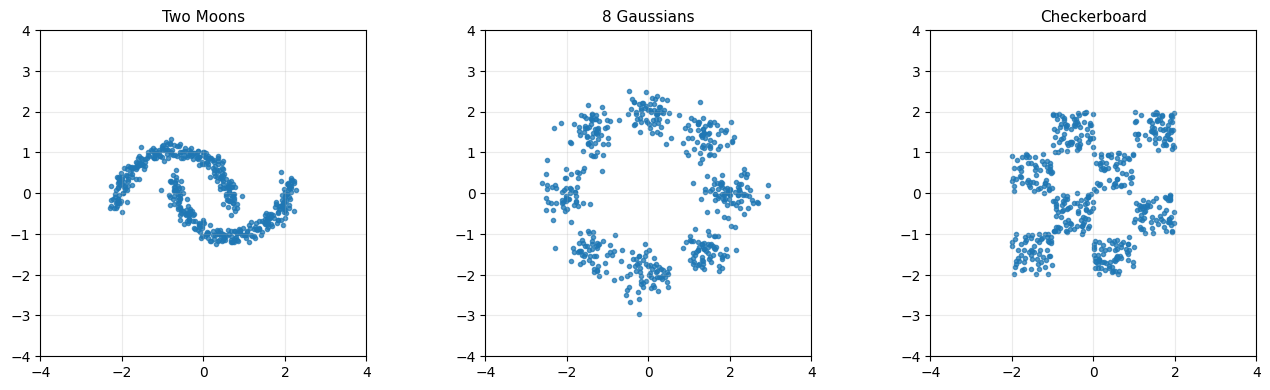

In [17]:
#@title Dataset generators matching Part B: Two Moons, 8 Gaussians, Checkerboard


def make_two_moons_partA(n, rng):
    """Generate standardized two-moons data in R^2, matching Part B."""
    if make_moons is not None:
        X, _ = make_moons(
            n_samples=n,
            noise=0.08,
            random_state=int(rng.integers(0, 999_999)),
        )
        X = X - X.mean(axis=0, keepdims=True)
        X = X / X.std()
        return X.astype(np.float64)

    # Fallback if sklearn is unavailable.
    n1 = n // 2
    n2 = n - n1
    th1 = rng.uniform(0, np.pi, n1)
    th2 = rng.uniform(0, np.pi, n2)
    moon1 = np.c_[np.cos(th1), np.sin(th1)]
    moon2 = np.c_[1 - np.cos(th2), 0.5 - np.sin(th2)]
    X = np.vstack([moon1, moon2])
    X += 0.08 * rng.standard_normal(X.shape)
    X = X - X.mean(axis=0, keepdims=True)
    X = X / X.std()
    return X.astype(np.float64)


def make_eight_gaussians_partA(n, rng):
    """Generate the eight-Gaussian ring dataset in R^2, matching Part B."""
    angles = np.linspace(0.0, 2.0 * np.pi, 8, endpoint=False)
    centers = 2.0 * np.column_stack([np.cos(angles), np.sin(angles)])
    idx = rng.integers(0, 8, size=n)
    X = centers[idx] + 0.3 * rng.standard_normal((n, 2))
    return X.astype(np.float64)


def make_checkerboard_partA(n, rng):
    """Generate the checkerboard dataset in R^2, matching Part B."""
    points = []
    while len(points) < n:
        xy = rng.uniform(-2.0, 2.0, size=(4 * n, 2))
        ix = np.floor(xy[:, 0] + 2.0).astype(int)
        iy = np.floor(xy[:, 1] + 2.0).astype(int)
        keep = (ix + iy) % 2 == 0
        points.extend(xy[keep].tolist())
    return np.asarray(points[:n], dtype=np.float64)


PART_A_DATASET_GENERATORS = {
    "Two Moons": make_two_moons_partA,
    "8 Gaussians": make_eight_gaussians_partA,
    "Checkerboard": make_checkerboard_partA,
}

# Fixed seeds make Part A reproducible while keeping the Part B generating rules.
PART_A_DATASET_SEEDS = {
    "Two Moons": 2025,
    "8 Gaussians": 3025,
    "Checkerboard": 4025,
}

datasets = {
    name: generator(N_DATA, np.random.default_rng(PART_A_DATASET_SEEDS[name]))
    for name, generator in PART_A_DATASET_GENERATORS.items()
}

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4))
for ax, (name, X) in zip(axes, datasets.items()):
    ax.scatter(X[:, 0], X[:, 1], s=9, alpha=0.75)
    ax.set_title(name)
    ax.set_aspect("equal")
    ax.set_xlim(X_LIM)
    ax.set_ylim(Y_LIM)
plt.tight_layout()
plt.show()


In [18]:
#@title Core empirical FM functions

def sigma_t(t, sigma_min=SIGMA_MIN):
    return 1.0 - (1.0 - sigma_min) * t

def make_grid(xlim=X_LIM, ylim=Y_LIM, n=GRID_N):
    xs = np.linspace(xlim[0], xlim[1], n)
    ys = np.linspace(ylim[0], ylim[1], n)
    XX, YY = np.meshgrid(xs, ys)
    Z = np.c_[XX.ravel(), YY.ravel()]
    return xs, ys, XX, YY, Z

xs, ys, XX, YY, GRID = make_grid()

def log_component_unnormalized(z, X, t, sigma_min=SIGMA_MIN):
    z = np.atleast_2d(z)
    s = sigma_t(t, sigma_min)
    diff = z[:, None, :] - t * X[None, :, :]
    return -0.5 * np.sum(diff**2, axis=2) / (s**2)

def responsibilities(z, X, t, sigma_min=SIGMA_MIN):
    logk = log_component_unnormalized(z, X, t, sigma_min)
    logw = logk - logsumexp(logk, axis=1, keepdims=True)
    return np.exp(logw)

def density_pt(z, X, t, sigma_min=SIGMA_MIN):
    z = np.atleast_2d(z)
    s = sigma_t(t, sigma_min)
    logk = log_component_unnormalized(z, X, t, sigma_min)
    d = z.shape[1]
    log_norm = -np.log(X.shape[0]) - d*np.log(s) - 0.5*d*np.log(2*np.pi)
    return np.exp(logsumexp(logk, axis=1) + log_norm)

def v_empirical(z, X, t, sigma_min=SIGMA_MIN):
    z = np.atleast_2d(z)
    w = responsibilities(z, X, t, sigma_min)
    xbar = w @ X
    s = sigma_t(t, sigma_min)
    return (xbar - (1.0 - sigma_min) * z) / s

def r_flux_null(z, X, t, omega=3.0, sigma_min=SIGMA_MIN):
    z = np.atleast_2d(z)
    w = responsibilities(z, X, t, sigma_min)
    s = sigma_t(t, sigma_min)
    centers_t = t * X
    diffs = z[:, None, :] - centers_t[None, :, :]
    A = omega * J
    rotated = diffs @ A.T
    return (s**2) * np.sum(w[:, :, None] * rotated, axis=1)

def u_flux_corrected(z, X, t, omega=3.0, sigma_min=SIGMA_MIN):
    return v_empirical(z, X, t, sigma_min) + r_flux_null(z, X, t, omega, sigma_min)

def curl_numeric(field_fn, z, X, t, eps=1e-3, **kwargs):
    z = np.atleast_2d(z)
    ex = np.array([[eps, 0.0]])
    ey = np.array([[0.0, eps]])
    f_xp = field_fn(z + ex, X, t, **kwargs)
    f_xm = field_fn(z - ex, X, t, **kwargs)
    f_yp = field_fn(z + ey, X, t, **kwargs)
    f_ym = field_fn(z - ey, X, t, **kwargs)
    dFy_dx = (f_xp[:, 1] - f_xm[:, 1]) / (2 * eps)
    dFx_dy = (f_yp[:, 0] - f_ym[:, 0]) / (2 * eps)
    return dFy_dx - dFx_dy

def divergence_numeric_vectorfield(vec_values, xs, ys):
    U = vec_values[..., 0]
    V = vec_values[..., 1]
    dx = xs[1] - xs[0]
    dy = ys[1] - ys[0]
    dU_dx = np.gradient(U, dx, axis=1)
    dV_dy = np.gradient(V, dy, axis=0)
    return dU_dx + dV_dy

def finite_difference_divergence_pr(X, t=0.55, omega=4.0):
    p = density_pt(GRID, X, t).reshape(GRID_N, GRID_N)
    r = r_flux_null(GRID, X, t, omega=omega).reshape(GRID_N, GRID_N, 2)
    current = p[..., None] * r
    div_current = divergence_numeric_vectorfield(current, xs, ys)
    return p, r, current, div_current


In [19]:
#@title Plot helpers

def plot_density_and_field(X, t=0.5, omega=0.0, title="", field="v"):
    if field == "v":
        F = v_empirical(GRID, X, t)
    elif field == "r":
        F = r_flux_null(GRID, X, t, omega=omega)
    elif field == "u":
        F = u_flux_corrected(GRID, X, t, omega=omega)
    else:
        raise ValueError("field must be 'v', 'r', or 'u'.")

    P = density_pt(GRID, X, t).reshape(GRID_N, GRID_N)
    Fgrid = F.reshape(GRID_N, GRID_N, 2)

    qxs = np.linspace(X_LIM[0], X_LIM[1], QUIVER_N)
    qys = np.linspace(Y_LIM[0], Y_LIM[1], QUIVER_N)
    QX, QY = np.meshgrid(qxs, qys)
    QZ = np.c_[QX.ravel(), QY.ravel()]

    if field == "v":
        QF = v_empirical(QZ, X, t)
    elif field == "r":
        QF = r_flux_null(QZ, X, t, omega=omega)
    else:
        QF = u_flux_corrected(QZ, X, t, omega=omega)

    plt.figure(figsize=(6, 5))
    plt.contourf(XX, YY, P, levels=40)
    plt.quiver(QX, QY, QF[:,0].reshape(QUIVER_N, QUIVER_N), QF[:,1].reshape(QUIVER_N, QUIVER_N), alpha=0.9)
    plt.scatter(t*X[:,0], t*X[:,1], s=5, alpha=0.35)
    plt.title(title or f"{field} field at t={t:.2f}")
    plt.xlim(X_LIM)
    plt.ylim(Y_LIM)
    plt.gca().set_aspect("equal")
    plt.show()

def plot_density_snapshots(X, name, times=(0.0, 0.25, 0.5, 0.75, 1.0)):
    fig, axes = plt.subplots(1, len(times), figsize=(4*len(times), 3.5))
    for ax, t in zip(axes, times):
        P = density_pt(GRID, X, t).reshape(GRID_N, GRID_N)
        ax.contourf(XX, YY, P, levels=35)
        ax.scatter(t*X[:,0], t*X[:,1], s=4, alpha=0.3)
        ax.set_title(f"t={t:.2f}")
        ax.set_xlim(X_LIM)
        ax.set_ylim(Y_LIM)
        ax.set_aspect("equal")
    fig.suptitle(f"Empirical marginal path: {name}")
    plt.tight_layout()
    plt.show()

def plot_curl(X, name, t=0.55):
    C = curl_numeric(v_empirical, GRID, X, t).reshape(GRID_N, GRID_N)
    P = density_pt(GRID, X, t).reshape(GRID_N, GRID_N)
    plt.figure(figsize=(6, 5))
    plt.contourf(XX, YY, C, levels=41)
    plt.contour(XX, YY, P, levels=8, colors="k", linewidths=0.5, alpha=0.4)
    plt.colorbar(label="curl of empirical velocity")
    plt.title(f"Empirical minimizer is generally non-gradient: {name}, t={t:.2f}")
    plt.xlim(X_LIM)
    plt.ylim(Y_LIM)
    plt.gca().set_aspect("equal")
    plt.show()
    print("mean |curl| on grid:", np.mean(np.abs(C)))
    print("max  |curl| on grid:", np.max(np.abs(C)))


## 3. Smoothed empirical marginal path

Run the next cell to see the density path $\widehat p_t$ from the base-like distribution at $t=0$ to the KDE at $t=1$.

Notice that $\sigma_{\min}$ controls the terminal kernel bandwidth. Smaller $\sigma_{\min}$ gives sharper KDE bumps around the data centers.


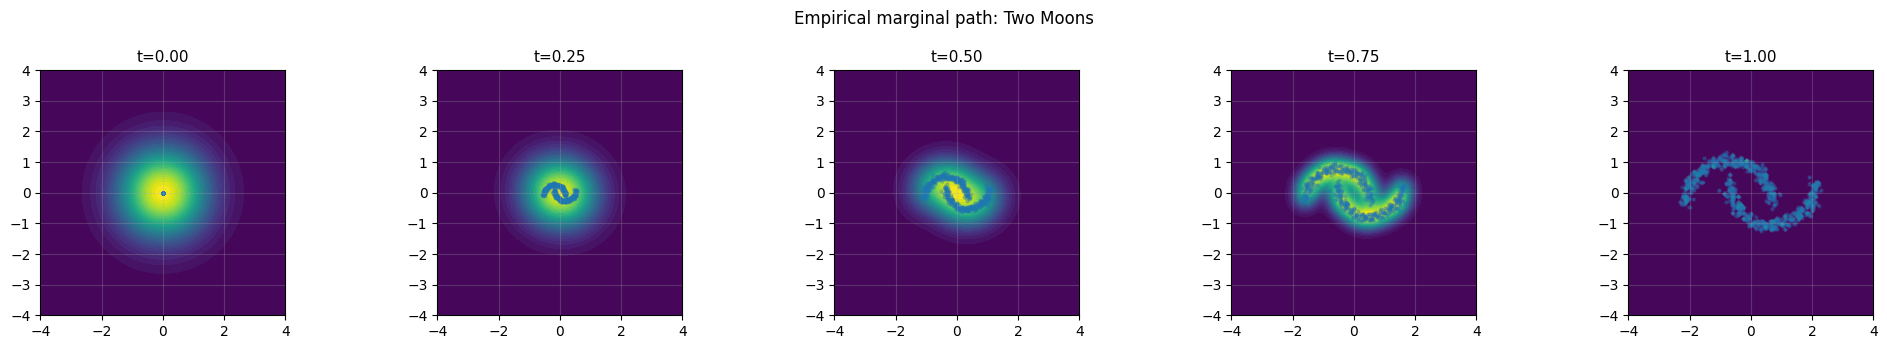

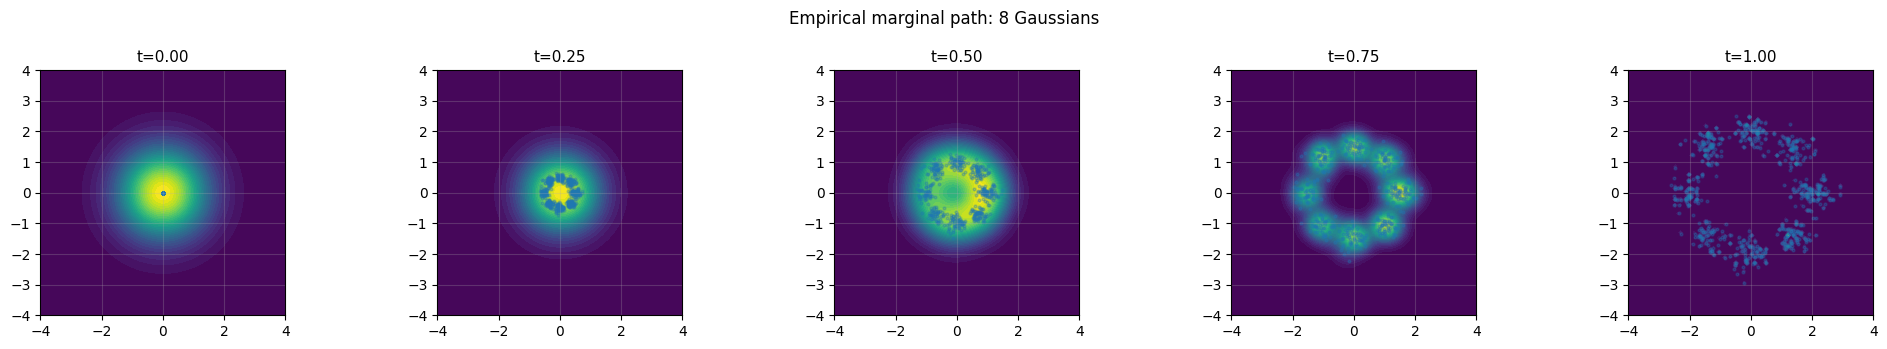

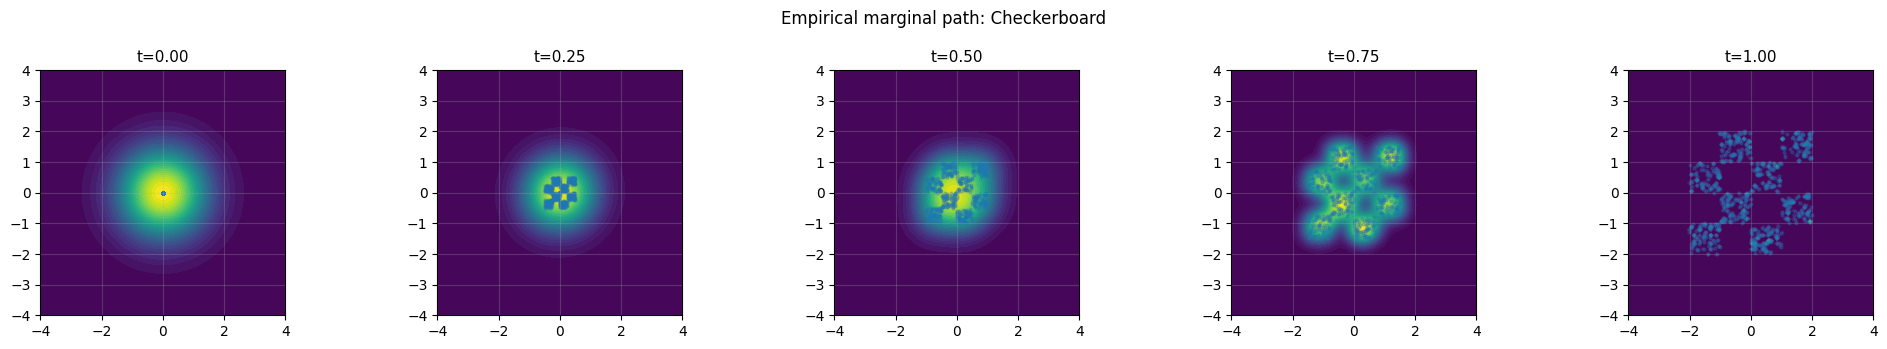

In [20]:
#@title Density path snapshots

for name, X in datasets.items():
    plot_density_snapshots(X, name)


## 4. Vector fields: original empirical minimizer and flux-null vector field correction

The field $\widehat v_t$ is selected by the square-loss empirical FM objective.

The field $r_t^A$ is not selected by this objective. It is a marginal-preserving correction. Adding it gives $u_t^A=\widehat v_t+r_t^A$.

The plots below compare: $\widehat v_t$, $r_t^A$, and $u_t^A$.

The correction is rotational because $A=\omega J$ is antisymmetric.



Two Moons


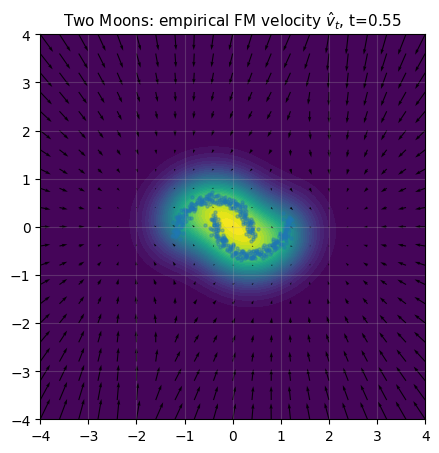

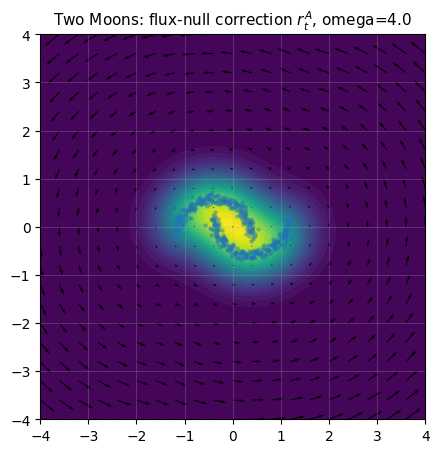

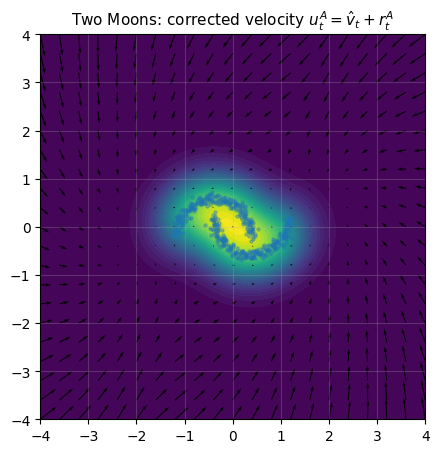


8 Gaussians


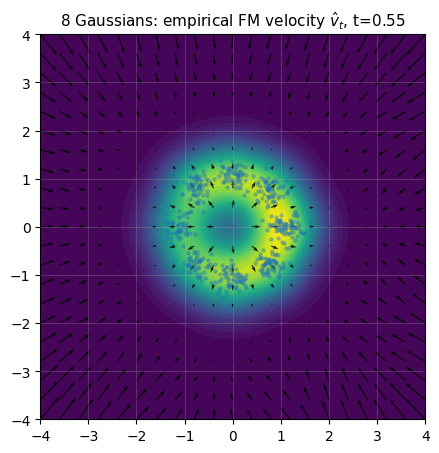

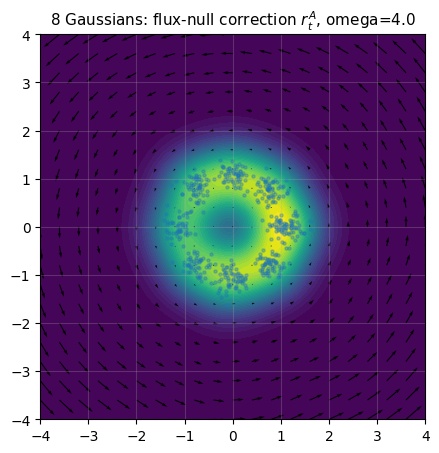

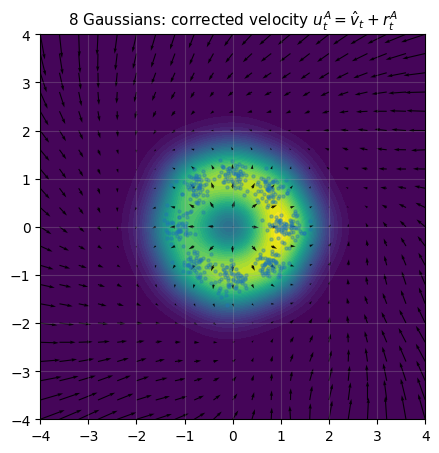


Checkerboard


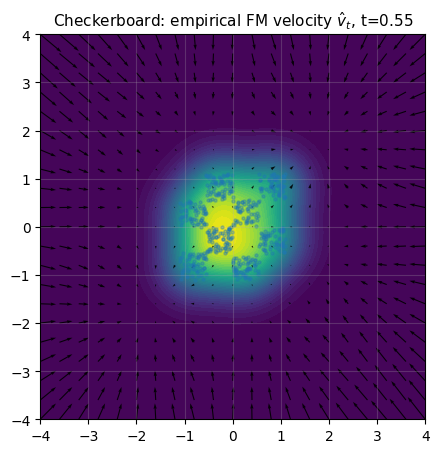

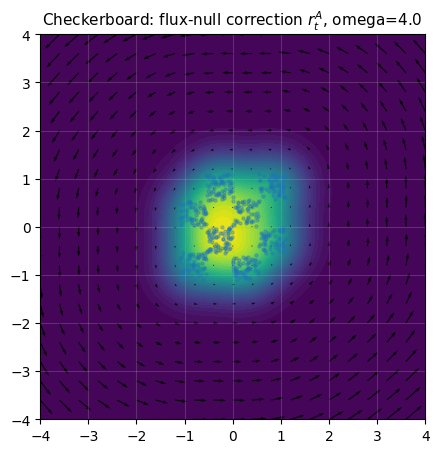

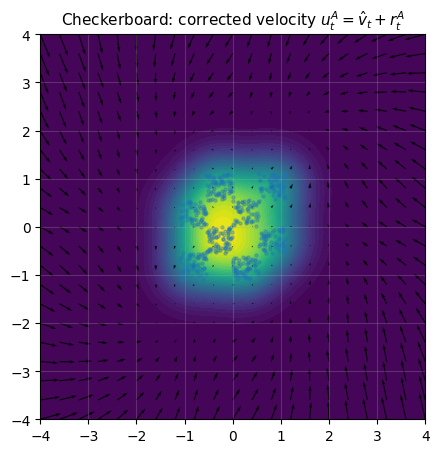

In [21]:
#@title Compare $\widehat v_t$, $r_t^A$, and $u_t^A$

t_show = 0.55
omega_show = 4.0

for name, X in datasets.items():
    print("\n" + "="*80)
    print(name)
    plot_density_and_field(X, t=t_show, field="v", title=f"{name}: empirical FM velocity $\\hat v_t$, t={t_show}")
    plot_density_and_field(X, t=t_show, field="r", omega=omega_show, title=f"{name}: flux-null correction $r_t^A$, omega={omega_show}")
    plot_density_and_field(X, t=t_show, field="u", omega=omega_show, title=f"{name}: corrected velocity $u_t^A=\\hat v_t+r_t^A$")


## 5. Numerical check: $\nabla \cdot(\widehat p_t r_t^A)\approx 0$

The theory says the probability current $\widehat p_t r_t^A$ is divergence-free.

Numerically, we approximate $\nabla \cdot(\widehat p_t r_t^A)$ by finite differences on a grid. Boundary and discretization errors are expected, but the divergence should be small in the high-density region.

The important distinction is:

- $\nabla \cdot r_t^A$ need not be zero,
- $\nabla \cdot(\widehat p_t r_t^A)$ is zero.

The density weight $\widehat p_t$ matters.



Two Moons
mean |div(p r)| over full grid: 4.2143630194698745e-05
mean |div(p r)| over top-density quartile: 0.00015785153027172952
max  |div(p r)| over top-density quartile: 0.00045191435085386103


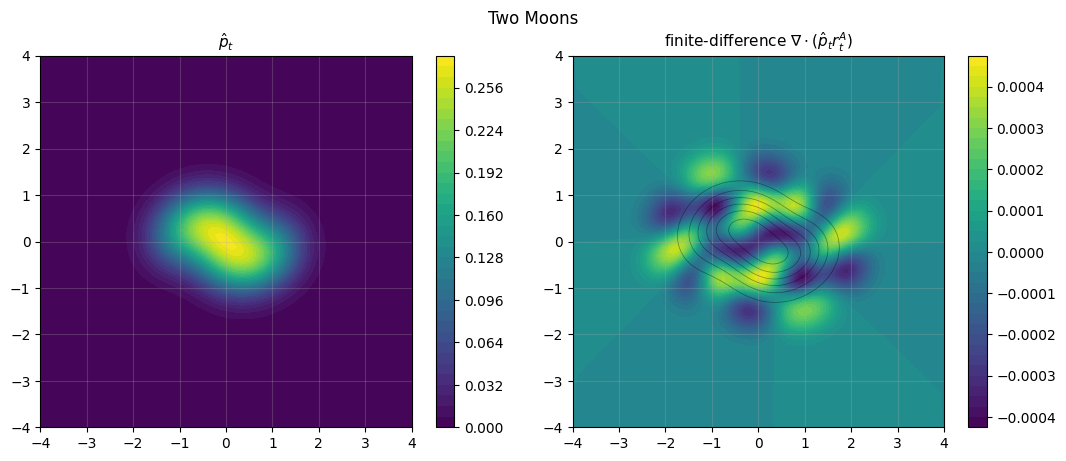


8 Gaussians
mean |div(p r)| over full grid: 3.9200461968248416e-05
mean |div(p r)| over top-density quartile: 0.00012405282223650432
max  |div(p r)| over top-density quartile: 0.0004770315745118558


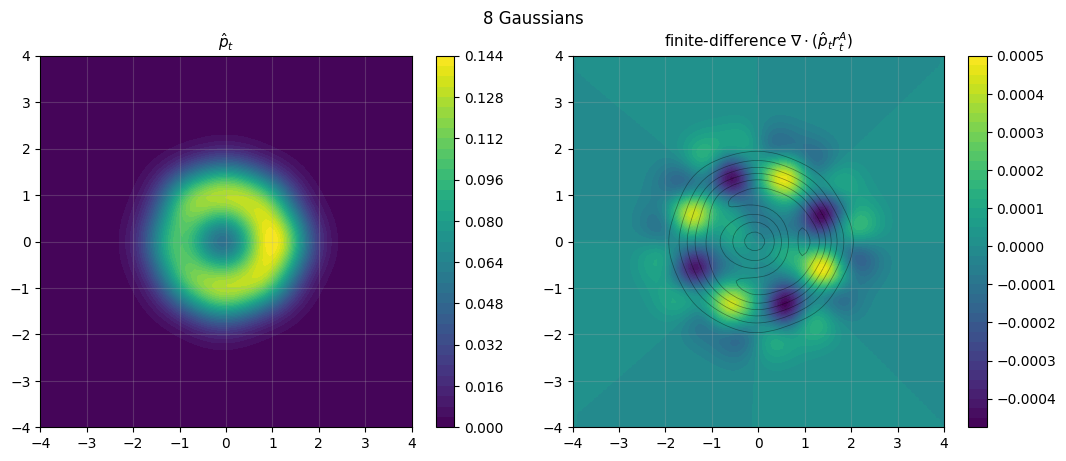


Checkerboard
mean |div(p r)| over full grid: 2.97465044209282e-05
mean |div(p r)| over top-density quartile: 0.00010189433931574908
max  |div(p r)| over top-density quartile: 0.0002945345214501044


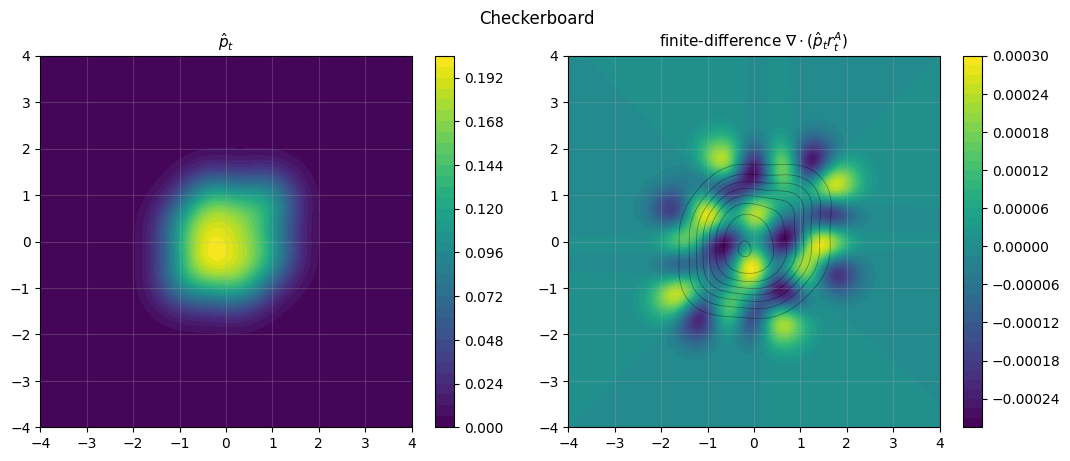

In [22]:
#@title Finite-difference divergence check for the probability current

t_div = 0.55
omega_div = 5.0

for name, X in datasets.items():
    p, r, current, div_current = finite_difference_divergence_pr(X, t=t_div, omega=omega_div)
    mask = p > np.quantile(p, 0.75)
    print("\n" + "="*80)
    print(name)
    print("mean |div(p r)| over full grid:", float(np.mean(np.abs(div_current))))
    print("mean |div(p r)| over top-density quartile:", float(np.mean(np.abs(div_current[mask]))))
    print("max  |div(p r)| over top-density quartile:", float(np.max(np.abs(div_current[mask]))))

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
    im0 = axes[0].contourf(XX, YY, p, levels=35)
    axes[0].set_title(r"$\hat p_t$")
    axes[0].set_aspect("equal")
    axes[0].set_xlim(X_LIM)
    axes[0].set_ylim(Y_LIM)
    plt.colorbar(im0, ax=axes[0])

    im1 = axes[1].contourf(XX, YY, div_current, levels=41)
    axes[1].contour(XX, YY, p, levels=8, colors="k", linewidths=0.5, alpha=0.4)
    axes[1].set_title(r"finite-difference $\nabla\cdot(\hat p_t r_t^A)$")
    axes[1].set_aspect("equal")
    axes[1].set_xlim(X_LIM)
    axes[1].set_ylim(Y_LIM)
    plt.colorbar(im1, ax=axes[1])
    plt.suptitle(name)
    plt.tight_layout()
    plt.show()


## 6. Empirical minimizer is generally not a gradient field

Even if each conditional velocity is a gradient field, the empirical minimizer is a spatially weighted mixture. The weights $w_i(t,z)$ vary with $z$, so the weighted mixture typically has nonzero curl.

In 2D, a smooth vector field is locally a gradient field only if its scalar curl is zero:

$$
\operatorname{curl} v = \partial_x v_2 - \partial_y v_1.
$$

The next cell computes the numerical curl of $\widehat v_t$.


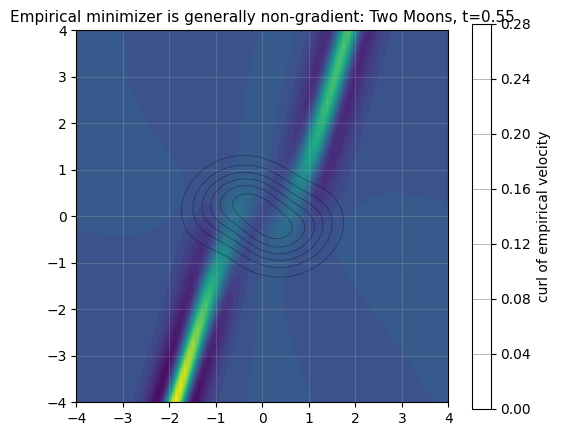

mean |curl| on grid: 2.2196824853962454e-07
max  |curl| on grid: 4.836371414462803e-06


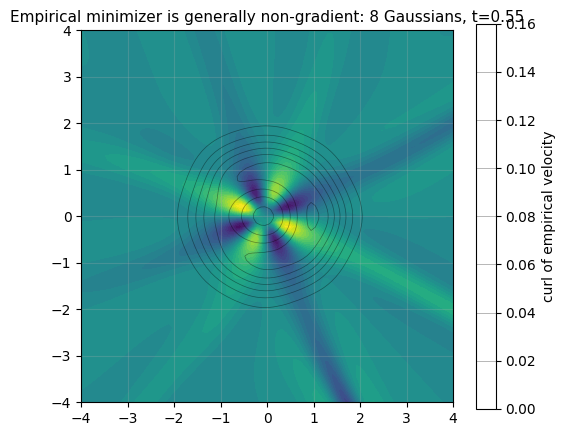

mean |curl| on grid: 2.869846366623805e-07
max  |curl| on grid: 3.59359392243519e-06


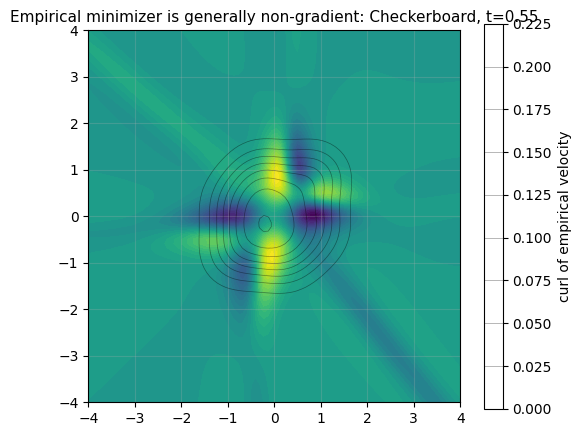

mean |curl| on grid: 8.12967624691489e-08
max  |curl| on grid: 1.2408135447936064e-06


In [23]:
#@title Numerical curl of the empirical minimizer

for name, X in datasets.items():
    plot_curl(X, name, t=0.55)


## 7. Same marginal path, different particle trajectories

We now solve ODEs for particles:

$$
\frac{dZ_t}{dt}=\widehat v_t(Z_t)
$$

and

$$
\frac{dZ_t}{dt}=u_t^A(Z_t)=\widehat v_t(Z_t)+r_t^A(Z_t).
$$

Both fields realize the same analytic marginal path $\widehat p_t$ in the continuity-equation sense, but the particles can move differently.

The animation overlays particles on the same analytic density $\widehat p_t$. The corrected dynamics often swirl around the same density path.


In [24]:
#@title ODE sampler and trajectory utilities

def euler_solve_particles(
    X0,
    X_data,
    omega=0.0,
    n_steps=160,
    corrected=False,
    sigma_min=SIGMA_MIN,
    T=T_VIS_END,
    return_energy=True,
):
    """Forward Euler solver for Part A visualizations.

    We default to T_VIS_END=0.97 to match the paper-figure empirical experiment horizon.
    The analytic density path itself is still defined up to t=1 because SIGMA_MIN>0.
    """
    times = np.linspace(0.0, T, n_steps + 1)
    dt = times[1] - times[0]
    Z = X0.copy()
    traj = np.empty((n_steps + 1, X0.shape[0], 2))
    traj[0] = Z
    energy = np.zeros(X0.shape[0])

    for k, t in enumerate(times[:-1]):
        if corrected:
            V = u_flux_corrected(Z, X_data, t, omega=omega, sigma_min=sigma_min)
        else:
            V = v_empirical(Z, X_data, t, sigma_min=sigma_min)
        if return_energy:
            energy += np.sum(V**2, axis=1) * dt
        Z = Z + dt * V
        traj[k+1] = Z

    return times, traj, energy


def animate_particles_on_density(X_data, traj_a, traj_b=None, omega=0.0, title="", every=5, T=T_VIS_END):
    times = np.linspace(0.0, T, traj_a.shape[0])
    frames = list(range(0, len(times), every))
    if frames[-1] != len(times) - 1:
        frames.append(len(times) - 1)

    fig, ax = plt.subplots(figsize=(6, 5))

    def update(frame_idx):
        k = frames[frame_idx]
        t = times[k]
        ax.clear()
        P = density_pt(GRID, X_data, t).reshape(GRID_N, GRID_N)
        ax.contourf(XX, YY, P, levels=35)
        ax.scatter(traj_a[k, :, 0], traj_a[k, :, 1], s=4, alpha=0.35, label="base velocity")
        if traj_b is not None:
            ax.scatter(traj_b[k, :, 0], traj_b[k, :, 1], s=4, alpha=0.35, label=f"flux-corrected, omega={omega}")
        ax.scatter(t*X_data[:, 0], t*X_data[:, 1], s=4, alpha=0.15)
        ax.set_title(f"{title}, t={t:.2f}")
        ax.set_xlim(X_LIM)
        ax.set_ylim(Y_LIM)
        ax.set_aspect("equal")
        ax.legend(loc="upper right", fontsize=8)

    ani = animation.FuncAnimation(fig, update, frames=len(frames), interval=120)
    plt.close(fig)
    return HTML(ani.to_jshtml())


def plot_selected_paths(traj_a, traj_b, title="", n_paths=35):
    rng = np.random.default_rng(123)
    idx = rng.choice(traj_a.shape[1], size=min(n_paths, traj_a.shape[1]), replace=False)
    plt.figure(figsize=(6, 5))
    for j in idx:
        plt.plot(traj_a[:, j, 0], traj_a[:, j, 1], alpha=0.35)
    for j in idx:
        plt.plot(traj_b[:, j, 0], traj_b[:, j, 1], alpha=0.35, linestyle="--")
    plt.title(title)
    plt.xlim(X_LIM)
    plt.ylim(Y_LIM)
    plt.gca().set_aspect("equal")
    plt.show()


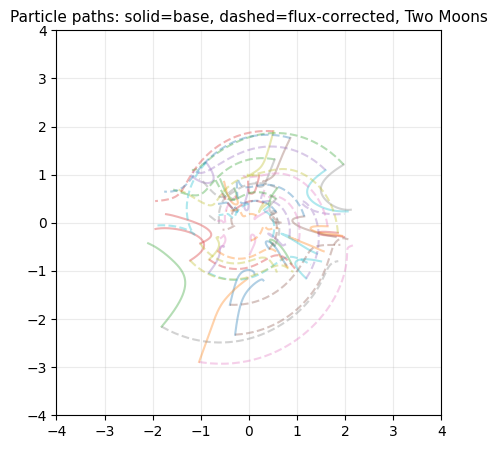

In [25]:
#@title Run particle trajectories for one dataset

dataset_name = "Two Moons"  # Try "8 Gaussians" or "Checkerboard" too.
omega_traj = 5.0
n_particles_demo = 1200
n_steps_demo = 180

X_data = datasets[dataset_name]
rng = np.random.default_rng(123)
X0 = rng.standard_normal((n_particles_demo, 2))

times, traj_base, E_base = euler_solve_particles(X0, X_data, corrected=False, n_steps=n_steps_demo)
_, traj_flux, E_flux = euler_solve_particles(X0, X_data, corrected=True, omega=omega_traj, n_steps=n_steps_demo)

plot_selected_paths(traj_base, traj_flux, title=f"Particle paths: solid=base, dashed=flux-corrected, {dataset_name}")

display(animate_particles_on_density(
    X_data,
    traj_base[::1, :700],
    traj_flux[::1, :700],
    omega=omega_traj,
    title=f"Same analytic marginal path, different particles: {dataset_name}",
    every=8
))


### Side-by-side GIF: same marginal density, different particle dynamics

The previous animation overlays the two particle systems in a single panel. That is useful, but it can be visually crowded.

The next cell creates a cleaner **side-by-side GIF**:

- left: baseline empirical FM velocity $\widehat v_t$,
- right: flux-corrected velocity $u_t^A=\widehat v_t+r_t^A$,
- both panels use the same analytic density background $\widehat p_t$ at each time.

This makes the key message visually explicit: the marginal density path is the same, but the particle dynamics are different.


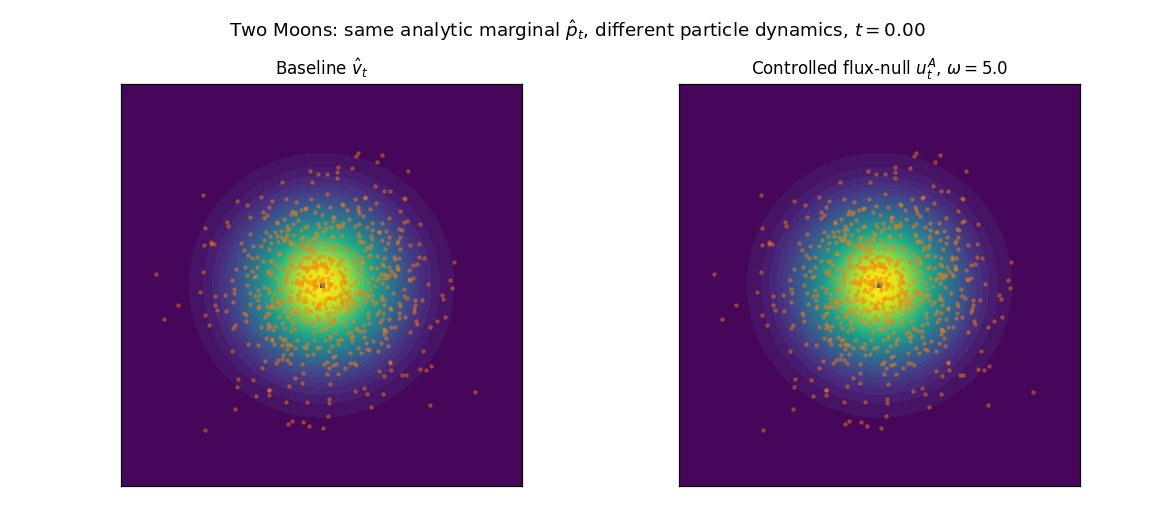

Saved side-by-side controlled flux-null GIF to: outputs_flux_null_gifs/two_moons_baseline_vs_controlled_fluxnull.gif


In [26]:
#@title Save GIF 1: baseline vs controlled flux-null correction

from pathlib import Path
from matplotlib.animation import PillowWriter
from IPython.display import Image, display

def save_side_by_side_particle_gif(
    X_data,
    traj_base,
    traj_flux,
    dataset_name="Two Moons",
    omega=5.0,
    gif_path="same_marginal_different_particles.gif",
    every=6,
    max_particles=700,
    T=T_VIS_END,
    fps=10,
    dpi=110,
):
    """
    Save a side-by-side GIF comparing baseline empirical FM dynamics
    and the controlled Gaussian-mixture flux-null corrected dynamics.

    Both panels use the same analytic marginal density p_hat_t as background.
    The figure size, axes limits, and subplot geometry are fixed across frames.
    """
    gif_path = Path(gif_path)
    gif_path.parent.mkdir(parents=True, exist_ok=True)

    n_time = traj_base.shape[0]
    times = np.linspace(0.0, T, n_time)

    frames = list(range(0, n_time, every))
    if frames[-1] != n_time - 1:
        frames.append(n_time - 1)

    n_show = min(max_particles, traj_base.shape[1])
    traj_base_show = traj_base[:, :n_show, :]
    traj_flux_show = traj_flux[:, :n_show, :]

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(10.5, 4.8),
        sharex=True,
        sharey=True,
        constrained_layout=False,
    )
    fig.subplots_adjust(left=0.055, right=0.985, bottom=0.08, top=0.84, wspace=0.08)

    for ax in axes:
        ax.set_xlim(X_LIM)
        ax.set_ylim(Y_LIM)
        ax.set_aspect("equal", adjustable="box")

    def draw(frame_id):
        k = frames[frame_id]
        t = times[k]
        P = density_pt(GRID, X_data, t).reshape(GRID_N, GRID_N)

        for ax in axes:
            ax.cla()
            ax.contourf(XX, YY, P, levels=35)
            ax.scatter(t * X_data[:, 0], t * X_data[:, 1], s=4, alpha=0.16)
            ax.set_xlim(X_LIM)
            ax.set_ylim(Y_LIM)
            ax.set_aspect("equal", adjustable="box")
            ax.set_xticks([])
            ax.set_yticks([])

        axes[0].scatter(
            traj_base_show[k, :, 0],
            traj_base_show[k, :, 1],
            s=4,
            alpha=0.35,
        )
        axes[0].set_title(r"Baseline $\hat v_t$", fontsize=11)

        axes[1].scatter(
            traj_flux_show[k, :, 0],
            traj_flux_show[k, :, 1],
            s=4,
            alpha=0.35,
        )
        axes[1].set_title(rf"Controlled flux-null $u_t^A$, $\omega={omega}$", fontsize=11)

        fig.suptitle(
            rf"{dataset_name}: same analytic marginal $\hat p_t$, different particle dynamics, $t={t:.2f}$",
            y=0.965,
            fontsize=12,
        )


    ani = animation.FuncAnimation(fig, draw, frames=len(frames), interval=1000 / fps)
    ani.save(gif_path, writer=PillowWriter(fps=fps), dpi=dpi)
    plt.close(fig)

    display(Image(filename=str(gif_path)))

    print(f"Saved side-by-side controlled flux-null GIF to: {gif_path}")
    return gif_path


# Example: make one side-by-side GIF for the dataset already simulated above.
gif_path = save_side_by_side_particle_gif(
    X_data=X_data,
    traj_base=traj_base,
    traj_flux=traj_flux,
    dataset_name=dataset_name,
    omega=omega_traj,
    gif_path=f"outputs_flux_null_gifs/{dataset_name.lower().replace(' ', '_')}_baseline_vs_controlled_fluxnull.gif",
    every=8,
    max_particles=700,
    fps=10,
)

### Side-by-side GIF 2: one-center polynomial-tail flux-null example

A plain scatter plot can be misleading here.

For the one-center path

$$
\widehat p_t= 𝒩(0,\sigma_t^2 I_2),
$$

the baseline dynamics and the explosive flux-null dynamics have the **same isotropic Gaussian marginal** at each time. Therefore, if all particles are plotted with the same color, the two panels can look almost identical.

To make the different particle dynamics visible, the next GIF uses two visual devices:

1. particles are colored by their **initial angle**;
2. a small number of particles are shown with short **trajectory trails**.

Under the baseline radial velocity, particles mostly move inward without changing angle.  
Under the explosive flux-null correction,

$$
r_t(z)=\exp\left(a\frac{\|z\|^2}{\sigma_t^2}\right)Jz,
\qquad 0<a<\frac14,
$$

particles rotate around the origin. The marginal density remains the same, but the labeled particle dynamics are different.

For numerical stability in the GIF, the default uses $a=0.12$ and $T=0.85$. This is still the same theoretical family $0<a<1/4$, but avoids artificial clipping of velocities in the animation.


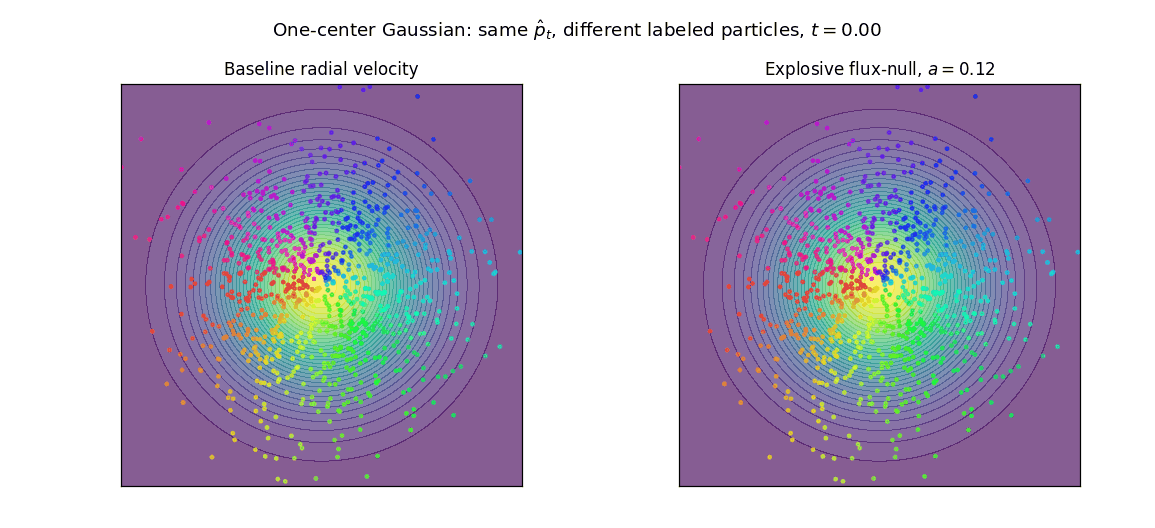

Saved colored/trail one-center flux-null GIF to: outputs_flux_null_gifs/one_center_colored_trails_polynomial_tail_fluxnull.gif
Median energy baseline: 1.16
Median energy corrected: 1.85
99% energy baseline: 7.81
99% energy corrected: 41.7


In [27]:
#@title Save GIF 2: one-center polynomial-tail flux-null correction with colors and trails

from pathlib import Path
from matplotlib.animation import PillowWriter

def one_center_base_velocity(z, t, sigma_min=SIGMA_MIN):
    z = np.atleast_2d(z)
    s = sigma_t(t, sigma_min)
    return -((1.0 - sigma_min) / s) * z

def one_center_explosive_flux_null(z, t, a=0.12, sigma_min=SIGMA_MIN):
    z = np.atleast_2d(z)
    s = sigma_t(t, sigma_min)
    radial = np.sum(z**2, axis=1, keepdims=True) / (s**2)
    return np.exp(a * radial) * (z @ J.T)

def one_center_corrected_velocity(z, t, a=0.12, sigma_min=SIGMA_MIN):
    return one_center_base_velocity(z, t, sigma_min) + one_center_explosive_flux_null(z, t, a, sigma_min)

def one_center_density_grid(t, xlim=(-3.0, 3.0), ylim=(-3.0, 3.0), n=90):
    xs_local = np.linspace(xlim[0], xlim[1], n)
    ys_local = np.linspace(ylim[0], ylim[1], n)
    XX_local, YY_local = np.meshgrid(xs_local, ys_local)
    Z_local = np.c_[XX_local.ravel(), YY_local.ravel()]
    s = sigma_t(t)
    P = (1.0 / (2 * np.pi * s**2)) * np.exp(-0.5 * np.sum(Z_local**2, axis=1) / s**2)
    return xs_local, ys_local, XX_local, YY_local, P.reshape(n, n)

def euler_solve_one_center(X0, corrected=False, a=0.12, n_steps=180, T=0.85):
    """
    Euler solve for the one-center caveat.

    The theoretical caveat concerns instantaneous tails and flux-null structure.
    For visualization, we use T<1 because the explosive rotational term can become
    extremely stiff near terminal time when sigma_t is small.
    """
    times = np.linspace(0.0, T, n_steps + 1)
    dt = times[1] - times[0]
    Z = X0.copy()
    traj = np.empty((n_steps + 1, X0.shape[0], 2))
    energy = np.zeros(X0.shape[0])
    traj[0] = Z

    for k, t in enumerate(times[:-1]):
        if corrected:
            V = one_center_corrected_velocity(Z, t, a=a)
        else:
            V = one_center_base_velocity(Z, t)

        energy += np.sum(V**2, axis=1) * dt
        Z = Z + dt * V
        traj[k + 1] = Z

    return times, traj, energy

def save_one_center_polynomial_tail_gif(
    a=0.12,
    n_particles=900,
    n_steps=180,
    T=0.85,
    gif_path="outputs_flux_null_gifs/one_center_colored_trails_polynomial_tail_fluxnull.gif",
    xlim=(-3.0, 3.0),
    ylim=(-3.0, 3.0),
    every=8,
    fps=10,
    dpi=110,
    seed=2026,
    n_trails=28,
):
    """
    Save a side-by-side GIF comparing the one-center baseline velocity
    with the explosive rotational flux-null correction.

    To make the difference visible despite identical isotropic marginals:
    - particles are colored by their initial angle;
    - selected particles have trajectory trails.
    """
    gif_path = Path(gif_path)
    gif_path.parent.mkdir(parents=True, exist_ok=True)

    rng = np.random.default_rng(seed)
    X0 = rng.standard_normal((n_particles, 2))

    # Initial-angle colors reveal angular transport.
    theta0 = np.arctan2(X0[:, 1], X0[:, 0])
    colors = (theta0 + np.pi) / (2 * np.pi)

    # Use a moderately long horizon. Close to t=1, the explosive field is very stiff.
    times, traj_base_one, E_base_one = euler_solve_one_center(
        X0, corrected=False, a=a, n_steps=n_steps, T=T
    )
    _, traj_poly_one, E_poly_one = euler_solve_one_center(
        X0, corrected=True, a=a, n_steps=n_steps, T=T
    )

    # Pick visible tracer particles from an outer annulus; rotation is easier to see there.
    radii0 = np.linalg.norm(X0, axis=1)
    candidate_idx = np.where((radii0 > np.quantile(radii0, 0.65)) & (radii0 < np.quantile(radii0, 0.95)))[0]
    if len(candidate_idx) < n_trails:
        candidate_idx = np.argsort(radii0)[-n_trails:]
    trail_idx = rng.choice(candidate_idx, size=min(n_trails, len(candidate_idx)), replace=False)

    frames = list(range(0, len(times), every))
    if frames[-1] != len(times) - 1:
        frames.append(len(times) - 1)

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(10.5, 4.8),
        sharex=True,
        sharey=True,
        constrained_layout=False,
    )
    fig.subplots_adjust(left=0.055, right=0.985, bottom=0.08, top=0.84, wspace=0.08)

    for ax in axes:
        ax.set_xlim(xlim)
        ax.set_ylim(ylim)
        ax.set_aspect("equal", adjustable="box")

    def draw(frame_id):
        k = frames[frame_id]
        t = times[k]
        _, _, XX_local, YY_local, P = one_center_density_grid(t, xlim=xlim, ylim=ylim, n=90)

        for ax in axes:
            ax.cla()
            ax.contourf(XX_local, YY_local, P, levels=35, alpha=0.65)
            ax.set_xlim(xlim)
            ax.set_ylim(ylim)
            ax.set_aspect("equal", adjustable="box")
            ax.set_xticks([])
            ax.set_yticks([])

        # Colored scatter: same marginal cloud, but labels reveal different transport.
        axes[0].scatter(
            traj_base_one[k, :, 0],
            traj_base_one[k, :, 1],
            c=colors,
            cmap="hsv",
            s=5,
            alpha=0.55,
            vmin=0,
            vmax=1,
        )
        axes[1].scatter(
            traj_poly_one[k, :, 0],
            traj_poly_one[k, :, 1],
            c=colors,
            cmap="hsv",
            s=5,
            alpha=0.55,
            vmin=0,
            vmax=1,
        )

        # Short trails for selected particles.
        trail_start = max(0, k - 28)
        for j in trail_idx:
            axes[0].plot(
                traj_base_one[trail_start:k+1, j, 0],
                traj_base_one[trail_start:k+1, j, 1],
                linewidth=0.9,
                alpha=0.55,
            )
            axes[1].plot(
                traj_poly_one[trail_start:k+1, j, 0],
                traj_poly_one[trail_start:k+1, j, 1],
                linewidth=0.9,
                alpha=0.55,
            )

        axes[0].set_title(r"Baseline radial velocity", fontsize=11)
        axes[1].set_title(rf"Explosive flux-null, $a={a}$", fontsize=11)

        fig.suptitle(
            rf"One-center Gaussian: same $\hat p_t$, different labeled particles, $t={t:.2f}$",
            y=0.965,
            fontsize=12,
        )

    ani = animation.FuncAnimation(fig, draw, frames=len(frames), interval=1000 / fps)
    ani.save(gif_path, writer=PillowWriter(fps=fps), dpi=dpi)
    display(Image(filename=str(gif_path)))
    plt.close(fig)

    print(f"Saved colored/trail one-center flux-null GIF to: {gif_path}")
    print(f"Median energy baseline: {np.median(E_base_one):.3g}")
    print(f"Median energy corrected: {np.median(E_poly_one):.3g}")
    print(f"99% energy baseline: {np.quantile(E_base_one, 0.99):.3g}")
    print(f"99% energy corrected: {np.quantile(E_poly_one, 0.99):.3g}")

    return gif_path, E_base_one, E_poly_one


gif_poly_path, E_base_one_gif, E_poly_one_gif = save_one_center_polynomial_tail_gif(
    a=0.12,
    n_particles=900,
    n_steps=180,
    T=0.85,
    gif_path="outputs_flux_null_gifs/one_center_colored_trails_polynomial_tail_fluxnull.gif",
    every=8,
    fps=10,
)


### Kinetic-energy tails for the same two dynamics

The GIF above shows the particle-level difference. The next plot shows the energetic consequence.

For each particle path, we approximate the integrated kinetic energy

$$
E_T=\int_0^T \|v_t(X_t)\|^2\,dt.
$$

The baseline radial dynamics and the explosive flux-null dynamics preserve the same one-time Gaussian marginals, but the flux-null correction can produce a much heavier upper tail for $E_T$.


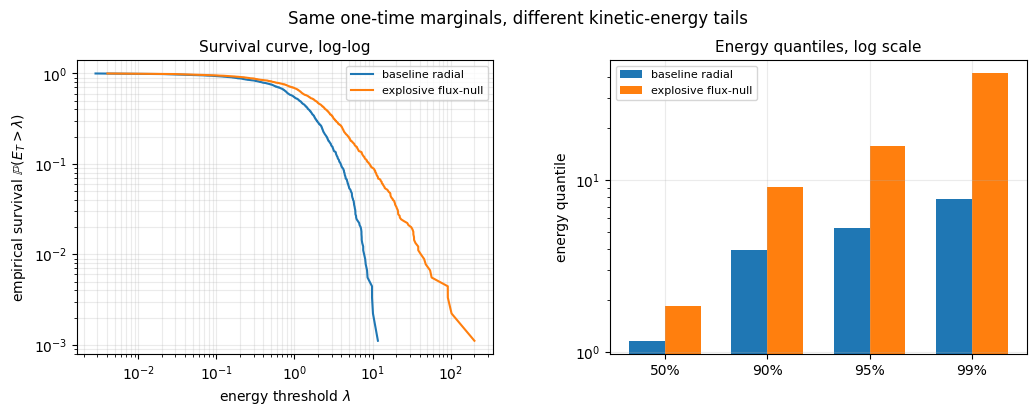

Energy-tail summary:
  median_baseline: 1.164
  median_flux_null: 1.853
  q99_baseline: 7.807
  q99_flux_null: 41.68
  q99_ratio: 5.339


In [28]:
#@title Plot KE-tail behavior immediately after the polynomial-tail GIF

def empirical_survival(values):
    values = np.sort(np.asarray(values))
    n = len(values)
    surv = 1.0 - np.arange(1, n + 1) / n
    mask = surv > 0
    return values[mask], surv[mask]

def plot_one_center_gif_energy_tails(E_base, E_flux, title="Integrated kinetic-energy tails"):
    xb, sb = empirical_survival(E_base)
    xf, sf = empirical_survival(E_flux)

    fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2), constrained_layout=False)
    fig.subplots_adjust(left=0.08, right=0.985, bottom=0.16, top=0.86, wspace=0.28)

    # Log-log survival: highlights heavy upper-tail behavior.
    axes[0].loglog(xb, sb, label="baseline radial")
    axes[0].loglog(xf, sf, label="explosive flux-null")
    axes[0].set_xlabel(r"energy threshold $\lambda$")
    axes[0].set_ylabel(r"empirical survival $\mathbb{P}(E_T>\lambda)$")
    axes[0].set_title("Survival curve, log-log")
    axes[0].grid(True, which="both", alpha=0.25)
    axes[0].legend()

    # Quantile comparison: easier to read at a glance.
    qs = np.array([0.50, 0.90, 0.95, 0.99])
    q_base = np.quantile(E_base, qs)
    q_flux = np.quantile(E_flux, qs)

    x = np.arange(len(qs))
    width = 0.35
    axes[1].bar(x - width/2, q_base, width, label="baseline radial")
    axes[1].bar(x + width/2, q_flux, width, label="explosive flux-null")
    axes[1].set_yscale("log")
    axes[1].set_xticks(x)
    axes[1].set_xticklabels([f"{int(100*q)}%" for q in qs])
    axes[1].set_ylabel(r"energy quantile")
    axes[1].set_title("Energy quantiles, log scale")
    axes[1].grid(True, axis="y", alpha=0.25)
    axes[1].legend()

    fig.suptitle(title, y=0.98)
    plt.show()

    summary = {
        "median_baseline": float(np.quantile(E_base, 0.50)),
        "median_flux_null": float(np.quantile(E_flux, 0.50)),
        "q99_baseline": float(np.quantile(E_base, 0.99)),
        "q99_flux_null": float(np.quantile(E_flux, 0.99)),
        "q99_ratio": float(np.quantile(E_flux, 0.99) / np.quantile(E_base, 0.99)),
    }
    print("Energy-tail summary:")
    for k, v in summary.items():
        print(f"  {k}: {v:.4g}")
    return summary


# These arrays are produced by the preceding polynomial-tail GIF cell.
# If this cell is run standalone, rerun the GIF cell first.
if "E_base_one_gif" not in globals() or "E_poly_one_gif" not in globals():
    raise RuntimeError(
        "Missing E_base_one_gif or E_poly_one_gif. "
        "Run the preceding polynomial-tail GIF cell first."
    )

one_center_energy_tail_summary = plot_one_center_gif_energy_tails(
    E_base_one_gif,
    E_poly_one_gif,
    title="Same one-time marginals, different kinetic-energy tails",
)


**Note.** This plot uses the integrated kinetic energies from the animated trajectories. It is meant to connect directly to the GIF, so it may not show a perfectly linear log-log tail. The cleaner paper-style caveat plot later in Part B isolates the fixed-time tail mechanism and shows the near-linear log-log behavior more clearly.

### Takeaway before looking at energy

The side-by-side trajectories show that marginal density plots are not enough to characterize a sampler.

Two samplers can agree on every one-time marginal $\widehat p_t$ but disagree on:

- particle paths,
- rotational behavior,
- numerical stiffness,
- kinetic energy.

The next section quantifies this last point.


## 8. Kinetic energy changes under flux-null corrections

Flux equivalence preserves the marginal density path, but it does not preserve kinetic energy.

For a trajectory $Z_t$, define the integrated kinetic energy

$$
E=\int_0^1 \|v_t(Z_t)\|^2\,dt.
$$

For the corrected velocity, the energy is

$$
E^A=\int_0^1 \|u^A_t(Z_t)\|^2\,dt.
$$

The next experiment compares the survival curves $\mathbb P(E>\lambda)$ for the original and flux-corrected velocities.

This illustrates a key point: a sampler can have the same one-time marginals but different trajectory-level behavior.


In [29]:
#@title Energy survival curve helper

def survival_curve(values):
    values = np.sort(np.asarray(values))
    n = len(values)
    surv = 1.0 - np.arange(1, n + 1) / n
    return values, surv

def plot_energy_survival(E_dict, title="Integrated kinetic energy survival"):
    plt.figure(figsize=(6, 4.5))
    for label, E in E_dict.items():
        x, y = survival_curve(E)
        mask = y > 0
        plt.loglog(x[mask], y[mask], label=label)
    plt.xlabel("energy threshold")
    plt.ylabel("empirical survival")
    plt.title(title)
    plt.legend()
    plt.grid(True, which="both", alpha=0.25)
    plt.show()


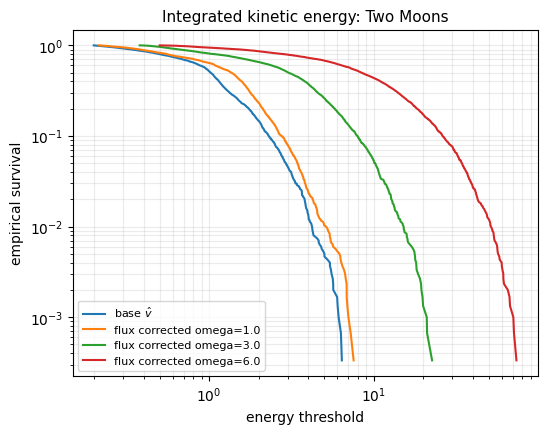

In [30]:
#@title Compare integrated kinetic-energy tails

dataset_name = "Two Moons"  # Try "8 Gaussians" or "Checkerboard" too.
X_data = datasets[dataset_name]

rng = np.random.default_rng(777)
X0 = rng.standard_normal((N_PARTICLES, 2))

energies = {}
_, _, energies["base $\\hat v$"] = euler_solve_particles(X0, X_data, corrected=False, n_steps=180)

for omega in [1.0, 3.0, 6.0]:
    _, _, E = euler_solve_particles(X0, X_data, corrected=True, omega=omega, n_steps=180)
    energies[f"flux corrected omega={omega}"] = E

plot_energy_survival(energies, title=f"Integrated kinetic energy: {dataset_name}")


## 9. A one-center example: flux-null corrections can drastically change energy tails

The paper also emphasizes a caveat: **flux equivalence alone does not control kinetic energy**.

Consider the one-center Gaussian path with $x_1=0$ in 2D. Then $\widehat p_t=𝒩(0,\sigma_t^2 I_2)$ and the standard velocity is radial:

$$
\widehat v_t(z)=-\frac{1-\sigma_{\min}}{\sigma_t}z.
$$

A rotational flux-null field is

$$
r_t(z)=\exp\left(a\frac{\|z\|^2}{\sigma_t^2}\right)Jz.
$$

For $0<a<1/4$, this field is still in $L^2(\widehat p_t)$, and $\nabla \cdot(\widehat p_t r_t)=0$, but its kinetic energy can have much heavier tails.

This is a useful warning:

> Same marginal density path does not mean same sampler behavior.


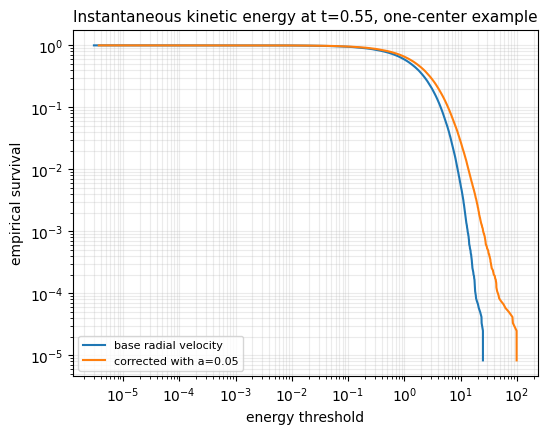

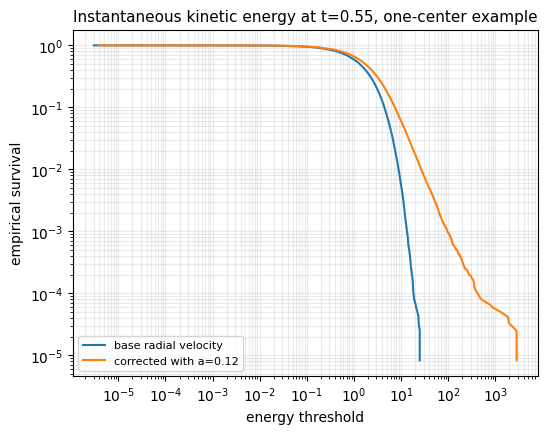

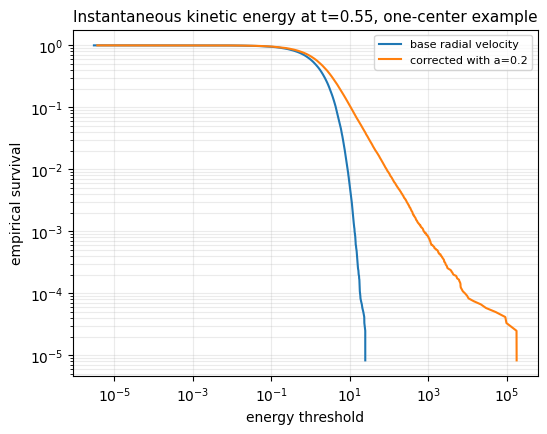

In [31]:
#@title One-center heavy-energy flux-null toy example

def one_center_base_velocity(z, t, sigma_min=SIGMA_MIN):
    z = np.atleast_2d(z)
    s = sigma_t(t, sigma_min)
    return -((1.0 - sigma_min) / s) * z

def one_center_explosive_flux_null(z, t, a=0.18, sigma_min=SIGMA_MIN):
    z = np.atleast_2d(z)
    s = sigma_t(t, sigma_min)
    radial = np.sum(z**2, axis=1, keepdims=True) / (s**2)
    return np.exp(a * radial) * (z @ J.T)

def one_center_corrected_velocity(z, t, a=0.18, sigma_min=SIGMA_MIN):
    return one_center_base_velocity(z, t, sigma_min) + one_center_explosive_flux_null(z, t, a, sigma_min)

def sample_from_one_center_pt(n=200000, t=0.55, seed=0):
    rng = np.random.default_rng(seed)
    return sigma_t(t) * rng.standard_normal((n, 2))

t_energy = 0.55
Z = sample_from_one_center_pt(n=120000, t=t_energy, seed=42)

K_base = np.sum(one_center_base_velocity(Z, t_energy)**2, axis=1)
for a in [0.05, 0.12, 0.20]:
    K_corr = np.sum(one_center_corrected_velocity(Z, t_energy, a=a)**2, axis=1)
    plot_energy_survival(
        {
            "base radial velocity": K_base,
            f"corrected with a={a}": K_corr,
        },
        title=f"Instantaneous kinetic energy at t={t_energy}, one-center example"
    )


## 10. What to take away

This notebook demonstrates the following points.

1. **Empirical target replacement changes the statistical target.** With $\sigma_{\min}>0$, the terminal law is not the empirical measure itself, but the KDE $\frac{1}{N}\sum_i 𝒩(x_i,\sigma_{\min}^2 I_2)$.

2. **The empirical FM minimizer is a posterior-weighted mixture.** The velocity $\widehat v_t$ averages conditional velocities using spatially varying weights $w_i(t,z)$.

3. **Weighted mixtures generally destroy gradient structure.** The numerical curl plots show that $\widehat v_t$ is typically not curl-free, even though the conditional building blocks are simple affine fields.

4. **Flux-null corrections preserve the marginal path.** Antisymmetric rotations produce $r_t^A$ satisfying $\nabla\cdot(\hat p_t r_t^A)=0$, so $\widehat v_t$ and $\widehat v_t+r_t^A$ solve the same continuity equation for $\widehat p_t$.

5. **Same marginals do not imply same particles.** The particle animations show visibly different trajectory-level dynamics over the same density path.

6. **Same marginals do not imply same energy.** Flux-null corrections can change kinetic energy profiles. With controlled linear growth, the source-tail mechanism remains controlled; without such control, energy tails can change drastically.


# Part B — Paper-figure experiments

Part B is the reproduction-oriented half of the notebook.  

The purpose is different from Part A:

- Part A explains **flux-null non-uniqueness** visually.
- Part B validates **source-driven kinetic-energy tails** numerically.

The two parts share the same datasets, so the examples are visually and statistically consistent.


# Kinetic Energy Tail Validation for Exact Empirical Affine Flow Matching

## Part I: Exact empirical affine FM sampler

For the scalar affine conditional path
$$Z_t = t x_i + s_t X_0,\qquad s_t = 1-(1-\sigma_{\min})t,$$
the exact empirical velocity is
$$\widehat v(t,z)
=
\sum_{i=1}^N w_i(t,z)
\frac{x_i-(1-\sigma_{\min})z}{s_t},
$$
where
$$
w_i(t,z)
=
\frac{K((z-tx_i)/s_t)}{\sum_{j=1}^N K((z-tx_j)/s_t)}.
$$
This is exactly the empirical affine-flow minimizer used in the notes. The factor $s_t^{-d}$ cancels in the posterior weights because $s_t$ is common across all samples.

We compute
$$
K_t=\|\widehat v(t,Z_t)\|^2,
\
E_T=\int_0^T \|\widehat v(t,Z_t)\|^2\,dt,
$$
using explicit Euler trajectories.

## Part II: Nondegenerate affine sharpness experiment

We also test the sharpness mechanism using
$$
\dot Z_t=AZ_t+b.
$$
With $Y_t=AZ_t+b$, we have $Y_t=e^{tA}(AX_0+b)$, hence
$$
E_T=\int_0^T\|e^{tA}(AX_0+b)\|^2\,dt.
$$
When $A$ is nonsingular, this quadratic form is comparable to $\|X_0\|^2$ in the tail, so Student-$t_\nu$ sources should show energy survival slopes close to $-\nu/2$.

In [32]:
#@title Uncomment if needed:
# Uncomment in Colab if needed:
# !pip -q install numpy scipy scikit-learn matplotlib pandas

from __future__ import annotations

import time
from dataclasses import dataclass
from pathlib import Path
from typing import Callable, Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.linalg import expm
from scipy.special import gammaln
from scipy.stats import t as student_t
from sklearn.datasets import make_moons

%matplotlib inline

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "black",
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "legend.fontsize": 8,
})

np.set_printoptions(precision=4, suppress=True)

## Parameters

The empirical-FM experiment is intentionally lightweight because the object of study is the exact empirical sampler, not a neural model.

For smoother empirical-FM tail plots, increase `M_GEN_EMPIRICAL` to `5000` or `10000`.

The sharpness experiment is cheap, so it uses more samples by default.

In [33]:
#@title Hidden implementation cell
# =============================================================================
# Experiment parameters
# =============================================================================

# Exact empirical FM validation
N_TRAIN = 500
M_GEN_EMPIRICAL = 1_000
N_SEEDS = 5
SEEDS = [2025 + 1000 * i for i in range(N_SEEDS)]

SIGMA_MIN = 0.02
T_END = 0.97
N_STEPS = 100
T_FRACTION_FOR_K = 0.55
CHUNK_SIZE = 1024
MAX_ENDPOINTS_STORED = 1000

# Sharpness validation for nondegenerate affine ODE
M_GEN_SHARPNESS = 100_000
SHARPNESS_DIM = 2
SHARPNESS_T_END = 1.0
SHARPNESS_N_STEPS = 400

# Output directories
OUTPUT_DIR = Path("outputs_draft_energy_tail")
FIG_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
for d in [OUTPUT_DIR, FIG_DIR, TABLE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Set to False if you already have cached CSV summaries and only want to inspect tables.
# Plot payloads require a fresh run because they store sample arrays for the first seed.
RUN_EMPIRICAL = True
RUN_SHARPNESS = True

print(f"Output directory: {OUTPUT_DIR.resolve()}")

Output directory: /content/outputs_draft_energy_tail


In [34]:
#@title Hidden implementation cell
# =============================================================================
# 1. Dataset generators for empirical FM
# =============================================================================

def make_two_moons(n: int, rng: np.random.Generator) -> np.ndarray:
    """Generate standardized two-moons data in R^2."""
    X, _ = make_moons(
        n_samples=n,
        noise=0.08,
        random_state=int(rng.integers(0, 999_999)),
    )
    X = X - X.mean(axis=0, keepdims=True)
    X = X / X.std()
    return X.astype(np.float64)


def make_eight_gaussians(n: int, rng: np.random.Generator) -> np.ndarray:
    """Generate an eight-Gaussian ring dataset in R^2."""
    angles = np.linspace(0.0, 2.0 * np.pi, 8, endpoint=False)
    centers = 2.0 * np.column_stack([np.cos(angles), np.sin(angles)])
    idx = rng.integers(0, 8, size=n)
    X = centers[idx] + 0.3 * rng.standard_normal((n, 2))
    return X.astype(np.float64)


def make_checkerboard(n: int, rng: np.random.Generator) -> np.ndarray:
    """Generate a simple two-dimensional checkerboard dataset."""
    points: list[list[float]] = []
    while len(points) < n:
        xy = rng.uniform(-2.0, 2.0, size=(4 * n, 2))
        ix = np.floor(xy[:, 0] + 2.0).astype(int)
        iy = np.floor(xy[:, 1] + 2.0).astype(int)
        keep = (ix + iy) % 2 == 0
        points.extend(xy[keep].tolist())
    return np.asarray(points[:n], dtype=np.float64)


DATASETS: dict[str, Callable[[int, np.random.Generator], np.ndarray]] = {
    "Two Moons": make_two_moons,
    "8 Gaussians": make_eight_gaussians,
    "Checkerboard": make_checkerboard,
}

In [35]:
#@title Hidden implementation cell
# =============================================================================
# 2. Base distributions and densities
# =============================================================================

@dataclass(frozen=True)
class BaseConfig:
    """Configuration for a source/base distribution."""
    label: str
    kind: str
    nu: Optional[float]
    color: str
    linestyle: str
    bound_benchmark_slope: Optional[float]


BASE_CONFIGS: list[BaseConfig] = [
    BaseConfig(
        label="Gaussian",
        kind="gaussian",
        nu=None,
        color="#1f77b4",
        linestyle="-",
        bound_benchmark_slope=None,
    ),
    BaseConfig(
        label="Student-t nu=10",
        kind="student",
        nu=10.0,
        color="#9467bd",
        linestyle=":",
        bound_benchmark_slope=-5.0,
    ),
    BaseConfig(
        label="Student-t nu=5",
        kind="student",
        nu=5.0,
        color="#ff7f0e",
        linestyle="--",
        bound_benchmark_slope=-2.5,
    ),
    BaseConfig(
        label="Student-t nu=2",
        kind="student",
        nu=2.0,
        color="#2ca02c",
        linestyle="-.",
        bound_benchmark_slope=-1.0,
    ),
]


def sample_base(
    n: int,
    d: int,
    cfg: BaseConfig,
    rng: np.random.Generator,
) -> np.ndarray:
    """Sample from the configured base distribution."""
    if cfg.kind == "gaussian":
        return rng.standard_normal((n, d)).astype(np.float64)

    if cfg.kind == "student":
        if cfg.nu is None:
            raise ValueError("Student-t base requires cfg.nu.")
        return student_t.rvs(
            df=cfg.nu,
            size=(n, d),
            random_state=int(rng.integers(0, 999_999_999)),
        ).astype(np.float64)

    raise ValueError(f"Unknown base kind: {cfg.kind!r}")


def log_base_density(y: np.ndarray, cfg: BaseConfig) -> np.ndarray:
    """
    Compute log K(y), where K is the source density.

    For Student-t, this uses independent coordinate-wise Student-t densities.
    """
    if cfg.kind == "gaussian":
        return -0.5 * np.sum(y * y, axis=-1)

    if cfg.kind == "student":
        if cfg.nu is None:
            raise ValueError("Student-t base requires cfg.nu.")
        nu = cfg.nu
        per_coord = (
            gammaln((nu + 1.0) / 2.0)
            - gammaln(nu / 2.0)
            - 0.5 * np.log(nu * np.pi)
            - ((nu + 1.0) / 2.0) * np.log1p((y * y) / nu)
        )
        return np.sum(per_coord, axis=-1)

    raise ValueError(f"Unknown base kind: {cfg.kind!r}")

In [36]:
#@title Hidden implementation cell
# =============================================================================
# 3. Exact empirical affine-flow velocity
# =============================================================================

def _batch_velocity_no_chunk(
    t: float,
    Z: np.ndarray,
    data: np.ndarray,
    sigma_min: float,
    cfg: BaseConfig,
) -> np.ndarray:
    """
    Exact empirical affine-flow velocity for one particle batch.

    Formula:
        s_t = 1 - (1 - sigma_min)t
        w_i(t,z) proportional to K((z - t x_i)/s_t)
        v_i(t,z) = [x_i - (1 - sigma_min) z] / s_t
        v_hat(t,z) = sum_i w_i(t,z) v_i(t,z)
    """
    s_t = 1.0 - (1.0 - sigma_min) * t
    if s_t <= 0.0:
        raise ValueError(
            f"s_t must be positive. Got s_t={s_t:.3e}. "
            "Use T < 1 when sigma_min=0, or sigma_min > 0."
        )

    standardized = (Z[:, None, :] - t * data[None, :, :]) / s_t
    log_w = log_base_density(standardized, cfg)

    # Stable softmax over training index i.
    log_w = log_w - np.max(log_w, axis=1, keepdims=True)
    w = np.exp(log_w)
    denom = np.sum(w, axis=1, keepdims=True)

    if np.any(denom <= 0.0) or not np.all(np.isfinite(denom)):
        raise FloatingPointError("Invalid posterior-weight denominator.")

    w = w / denom

    conditional_velocity = (
        data[None, :, :] - (1.0 - sigma_min) * Z[:, None, :]
    ) / s_t

    return np.einsum("mn,mnd->md", w, conditional_velocity)


def batch_velocity(
    t: float,
    Z: np.ndarray,
    data: np.ndarray,
    sigma_min: float,
    cfg: BaseConfig,
    chunk_size: int = CHUNK_SIZE,
) -> np.ndarray:
    """
    Memory-safe exact empirical affine-flow velocity.

    Splits particles into chunks to avoid allocating a large
    (M_gen, N_train, d) tensor at once.
    """
    if Z.ndim != 2:
        raise ValueError("Z must have shape (M, d).")

    if chunk_size <= 0:
        return _batch_velocity_no_chunk(t, Z, data, sigma_min, cfg)

    V = np.empty_like(Z, dtype=np.float64)
    for start in range(0, Z.shape[0], chunk_size):
        end = min(start + chunk_size, Z.shape[0])
        V[start:end] = _batch_velocity_no_chunk(
            t=t,
            Z=Z[start:end],
            data=data,
            sigma_min=sigma_min,
            cfg=cfg,
        )
    return V

In [37]:
#@title Hidden implementation cell
# =============================================================================
# 4. Euler integration and kinetic-energy accumulation for empirical FM
# =============================================================================

def integrate_empirical_euler(
    X0: np.ndarray,
    data: np.ndarray,
    cfg: BaseConfig,
    sigma_min: float = SIGMA_MIN,
    T: float = T_END,
    n_steps: int = N_STEPS,
    t_fraction_for_K: float = T_FRACTION_FOR_K,
    chunk_size: int = CHUNK_SIZE,
    max_endpoints_stored: Optional[int] = MAX_ENDPOINTS_STORED,
    rng_for_endpoint_subsample: Optional[np.random.Generator] = None,
) -> dict[str, np.ndarray]:
    """
    Integrate the exact empirical ODE using forward Euler.

    Update:
        Z_{k+1} = Z_k + dt * v_hat(t_k, Z_k)

    Energy:
        K_k = ||v_hat(t_k, Z_k)||^2
        E_T is approximated by the left-endpoint sum sum_k dt * K_k.

    Note:
        The left-endpoint rule is paired with the forward Euler trajectory used here.
        The affine sharpness experiment below uses trapezoidal quadrature because it
        evaluates an exact closed-form velocity expression rather than an Euler path.
    """
    if X0.ndim != 2:
        raise ValueError("X0 must have shape (M, d).")
    if data.ndim != 2:
        raise ValueError("data must have shape (N, d).")
    if X0.shape[1] != data.shape[1]:
        raise ValueError("X0 and data must have the same dimension.")
    if not (0.0 <= sigma_min < 1.0):
        raise ValueError("Expected 0 <= sigma_min < 1 for this experiment.")
    if sigma_min == 0.0 and T >= 1.0:
        raise ValueError("For unregularized RF, require T < 1.")
    if not (0.0 < T <= 1.0):
        raise ValueError("T must be in (0, 1].")
    if n_steps < 1:
        raise ValueError("n_steps must be positive.")

    M = X0.shape[0]
    ts = np.linspace(0.0, T, n_steps + 1)
    dt = ts[1] - ts[0]
    Z = X0.copy()

    E_T = np.zeros(M, dtype=np.float64)

    mid_index = int(np.clip(t_fraction_for_K * n_steps, 0, n_steps - 1))
    K_mid = None
    t_mid = ts[mid_index]

    for k in range(n_steps):
        t_k = ts[k]
        V = batch_velocity(t_k, Z, data, sigma_min, cfg, chunk_size)

        K = np.sum(V * V, axis=1)
        E_T += dt * K

        if k == mid_index:
            K_mid = K.copy()

        Z = Z + dt * V

    assert K_mid is not None, "K_mid was never set; check mid_index versus loop range."

    if rng_for_endpoint_subsample is None:
        rng_for_endpoint_subsample = np.random.default_rng(0)

    if max_endpoints_stored is not None and Z.shape[0] > max_endpoints_stored:
        idx = rng_for_endpoint_subsample.choice(Z.shape[0], size=max_endpoints_stored, replace=False)
        Z_plot = Z[idx]
    else:
        Z_plot = Z

    return {
        "E_T": E_T,
        "K_mid": K_mid,
        "t_mid": np.array(t_mid),
        "Z_plot": Z_plot,
        "ts": ts,
    }

In [38]:
#@title Hidden implementation cell
# =============================================================================
# 5. Survival functions and tail diagnostics
# =============================================================================

def empirical_survival(
    values: np.ndarray,
    n_pts: int = 200,
    q_min: float = 0.50,
    q_max: float = 0.99,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Empirical survival curve P(values > u), evaluated on quantile-spaced u.

    With M_GEN_EMPIRICAL=1000, q_max=0.99 is more stable than 0.995.
    For the sharpness experiment with many more samples, this default still works.
    """
    x = np.asarray(values, dtype=np.float64)
    x = x[np.isfinite(x)]

    if x.size < 10:
        raise ValueError("Need at least 10 finite values for survival curve.")

    quantiles = np.linspace(q_min, q_max, n_pts)
    u = np.quantile(x, quantiles)
    u = np.unique(u)
    sf = np.array([(x > threshold).mean() for threshold in u], dtype=np.float64)
    return u, sf


def fit_loglog_slope(
    u: np.ndarray,
    sf: np.ndarray,
    tail_fraction: float = 0.25,
    min_points: int = 15,
) -> float:
    """
    Fit log P(X>u) = a + b log u in the upper tail.

    This is a finite-sample diagnostic. In the empirical-FM experiment,
    it is not expected to equal the theorem's upper-bound benchmark exactly.
    """
    mask = (u > 0.0) & (sf > 0.0) & np.isfinite(u) & np.isfinite(sf)
    lu = np.log(u[mask])
    ls = np.log(sf[mask])

    if lu.size < min_points:
        return np.nan

    n_tail = max(min_points, int(tail_fraction * lu.size))
    n_tail = min(n_tail, lu.size)
    slope, _intercept = np.polyfit(lu[-n_tail:], ls[-n_tail:], 1)
    return float(slope)


def fit_loglinear_r2(
    u: np.ndarray,
    sf: np.ndarray,
    tail_fraction: float = 0.50,
    min_points: int = 15,
) -> float:
    """R-squared for log P(X>u) = a + b u in the upper tail."""
    mask = (sf > 0.0) & np.isfinite(u) & np.isfinite(sf)
    uu = u[mask]
    ls = np.log(sf[mask])

    if uu.size < min_points:
        return np.nan

    n_tail = max(min_points, int(tail_fraction * uu.size))
    n_tail = min(n_tail, uu.size)

    uu_tail = uu[-n_tail:]
    ls_tail = ls[-n_tail:]
    coeff = np.polyfit(uu_tail, ls_tail, 1)
    pred = np.polyval(coeff, uu_tail)

    ss_res = np.sum((ls_tail - pred) ** 2)
    ss_tot = np.sum((ls_tail - np.mean(ls_tail)) ** 2)

    if ss_tot <= 1e-14:
        return 1.0

    return float(1.0 - ss_res / ss_tot)


def hill_tail_index(
    values: np.ndarray,
    k: Optional[int] = None,
) -> float:
    """
    Hill estimator for the survival tail index beta in P(X>u) ~ u^{-beta}.

    This is noisy for small samples and should be interpreted only qualitatively.
    """
    x = np.asarray(values, dtype=np.float64)
    x = x[np.isfinite(x) & (x > 0.0)]

    if x.size < 50:
        return np.nan

    x_sorted = np.sort(x)
    n = x_sorted.size

    if k is None:
        k = max(20, int(np.sqrt(n)))

    k = min(max(k, 5), n - 1)

    top = x_sorted[-k:]
    threshold = x_sorted[-k - 1]

    if threshold <= 0.0:
        return np.nan

    gamma_hat = np.mean(np.log(top) - np.log(threshold))

    if gamma_hat <= 0.0:
        return np.nan

    return float(1.0 / gamma_hat)


def summarize_energy_values(values: np.ndarray) -> dict[str, float]:
    """Common scalar summaries for energy arrays."""
    return {
        "mean": float(np.mean(values)),
        "median": float(np.median(values)),
        "q90": float(np.quantile(values, 0.90)),
        "q95": float(np.quantile(values, 0.95)),
        "q99": float(np.quantile(values, 0.99)),
    }

In [39]:
#@title Hidden implementation cell
# =============================================================================
# 6. Run one empirical-FM dataset/base/seed experiment
# =============================================================================

def run_single_empirical_experiment(
    dataset_name: str,
    factory: Callable[[int, np.random.Generator], np.ndarray],
    cfg: BaseConfig,
    seed: int,
    dataset_seed_offset: int,
    base_seed_offset: int,
) -> tuple[dict, dict]:
    """
    Run one empirical-FM dataset/base/seed combination.

    Returns:
        summary_row: scalar diagnostics for tables
        plot_payload: E_T, K_mid, and endpoint subsample for optional plotting
    """
    rng_data = np.random.default_rng(seed + dataset_seed_offset)
    data = factory(N_TRAIN, rng_data)

    rng_base = np.random.default_rng(seed + base_seed_offset)
    X0 = sample_base(M_GEN_EMPIRICAL, data.shape[1], cfg, rng_base)

    rng_plot = np.random.default_rng(seed + dataset_seed_offset + base_seed_offset + 17)

    result = integrate_empirical_euler(
        X0=X0,
        data=data,
        cfg=cfg,
        sigma_min=SIGMA_MIN,
        T=T_END,
        n_steps=N_STEPS,
        t_fraction_for_K=T_FRACTION_FOR_K,
        chunk_size=CHUNK_SIZE,
        max_endpoints_stored=MAX_ENDPOINTS_STORED,
        rng_for_endpoint_subsample=rng_plot,
    )

    E_T = result["E_T"]
    K_mid = result["K_mid"]

    u_E, sf_E = empirical_survival(E_T)
    u_K, sf_K = empirical_survival(K_mid)

    E_summary = summarize_energy_values(E_T)
    K_summary = summarize_energy_values(K_mid)

    summary_row = {
        "experiment": "empirical_FM",
        "dataset": dataset_name,
        "base": cfg.label,
        "seed": seed,
        "bound_benchmark_slope": cfg.bound_benchmark_slope,
        "E_loglog_slope_fitted": fit_loglog_slope(u_E, sf_E),
        "E_loglinear_R2": fit_loglinear_r2(u_E, sf_E),
        "E_Hill_beta": hill_tail_index(E_T),
        "K_mid_loglog_slope_fitted": fit_loglog_slope(u_K, sf_K),
        "K_mid_loglinear_R2": fit_loglinear_r2(u_K, sf_K),
        "K_mid_Hill_beta": hill_tail_index(K_mid),
        "E_mean": E_summary["mean"],
        "E_median": E_summary["median"],
        "E_q90": E_summary["q90"],
        "E_q95": E_summary["q95"],
        "E_q99": E_summary["q99"],
        "K_mid_mean": K_summary["mean"],
        "K_mid_median": K_summary["median"],
        "K_mid_q90": K_summary["q90"],
        "K_mid_q95": K_summary["q95"],
        "K_mid_q99": K_summary["q99"],
        "integrator": "Euler",
        "n_steps": N_STEPS,
        "M_gen": M_GEN_EMPIRICAL,
        "N_train": N_TRAIN,
        "sigma_min": SIGMA_MIN,
        "T_end": T_END,
        "t_mid": float(result["t_mid"]),
    }

    plot_payload = {
        "dataset": dataset_name,
        "base": cfg.label,
        "cfg": cfg,
        "seed": seed,
        "data": data,
        "E_T": E_T,
        "K_mid": K_mid,
        "Z_plot": result["Z_plot"],
        "t_mid": float(result["t_mid"]),
    }

    return summary_row, plot_payload

## Part I: Run empirical-FM validation

This validates the **upper-tail transfer mechanism** for the exact empirical affine FM sampler.

The fitted log-log slopes are diagnostics, not theorem targets.

In [40]:
#@title Hidden implementation cell
# =============================================================================
# 7. Run empirical-FM experiments
# =============================================================================

empirical_by_seed_path = TABLE_DIR / "empirical_FM_tail_summary_by_seed.csv"

if RUN_EMPIRICAL:
    empirical_summary_rows: list[dict] = []
    empirical_plot_payloads_first_seed: dict[str, dict[str, dict]] = {}

    for dataset_index, (dataset_name, factory) in enumerate(DATASETS.items()):
        empirical_plot_payloads_first_seed[dataset_name] = {}

        for base_index, cfg in enumerate(BASE_CONFIGS):
            for seed_index, seed in enumerate(SEEDS):
                t0 = time.time()
                print(
                    f"[empirical FM] dataset={dataset_name}, base={cfg.label}, "
                    f"seed={seed_index + 1}/{N_SEEDS} ...",
                    end=" ",
                    flush=True,
                )

                row, plot_payload = run_single_empirical_experiment(
                    dataset_name=dataset_name,
                    factory=factory,
                    cfg=cfg,
                    seed=seed,
                    dataset_seed_offset=10_000 * dataset_index,
                    base_seed_offset=100_000 * (base_index + 1),
                )
                empirical_summary_rows.append(row)

                if seed_index == 0:
                    empirical_plot_payloads_first_seed[dataset_name][cfg.label] = plot_payload

                print(f"{time.time() - t0:.1f}s")

    empirical_by_seed_df = pd.DataFrame(empirical_summary_rows)
    empirical_by_seed_df.to_csv(empirical_by_seed_path, index=False)
else:
    if not empirical_by_seed_path.exists():
        raise FileNotFoundError(
            f"Cached empirical summary not found: {empirical_by_seed_path}. "
            "Set RUN_EMPIRICAL=True and rerun this section."
        )
    empirical_by_seed_df = pd.read_csv(empirical_by_seed_path)
    empirical_plot_payloads_first_seed = {}
    print("Loaded cached empirical summary. Set RUN_EMPIRICAL=True to regenerate plot payloads.")

print(f"Saved empirical-FM by-seed summary: {empirical_by_seed_path}")
display(empirical_by_seed_df.head())

[empirical FM] dataset=Two Moons, base=Gaussian, seed=1/5 ... 5.9s
[empirical FM] dataset=Two Moons, base=Gaussian, seed=2/5 ... 4.6s
[empirical FM] dataset=Two Moons, base=Gaussian, seed=3/5 ... 5.0s
[empirical FM] dataset=Two Moons, base=Gaussian, seed=4/5 ... 5.5s
[empirical FM] dataset=Two Moons, base=Gaussian, seed=5/5 ... 4.6s
[empirical FM] dataset=Two Moons, base=Student-t nu=10, seed=1/5 ... 7.7s
[empirical FM] dataset=Two Moons, base=Student-t nu=10, seed=2/5 ... 6.4s
[empirical FM] dataset=Two Moons, base=Student-t nu=10, seed=3/5 ... 7.7s
[empirical FM] dataset=Two Moons, base=Student-t nu=10, seed=4/5 ... 6.6s
[empirical FM] dataset=Two Moons, base=Student-t nu=10, seed=5/5 ... 7.5s
[empirical FM] dataset=Two Moons, base=Student-t nu=5, seed=1/5 ... 7.5s
[empirical FM] dataset=Two Moons, base=Student-t nu=5, seed=2/5 ... 6.8s
[empirical FM] dataset=Two Moons, base=Student-t nu=5, seed=3/5 ... 7.7s
[empirical FM] dataset=Two Moons, base=Student-t nu=5, seed=4/5 ... 6.6s
[em

,experiment,dataset,base,seed,bound_benchmark_slope,E_loglog_slope_fitted,E_loglinear_R2,E_Hill_beta,K_mid_loglog_slope_fitted,K_mid_loglinear_R2,...,K_mid_q90,K_mid_q95,K_mid_q99,integrator,n_steps,M_gen,N_train,sigma_min,T_end,t_mid
0,empirical_FM,Two Moons,Gaussian,2025,NaN,-3.074039,0.990976,5.130943,-2.114211,0.977250,...,1.323806,1.949802,3.407751,Euler,100,1000,500,0.02,0.97,0.5335
1,empirical_FM,Two Moons,Gaussian,3025,NaN,-4.126399,0.993362,4.562492,-2.699147,0.992281,...,1.215220,1.648384,2.708835,Euler,100,1000,500,0.02,0.97,0.5335
2,empirical_FM,Two Moons,Gaussian,4025,NaN,-3.416543,0.993580,6.006956,-2.536749,0.983384,...,1.232890,1.574244,2.756111,Euler,100,1000,500,0.02,0.97,0.5335
3,empirical_FM,Two Moons,Gaussian,5025,NaN,-3.131138,0.997882,4.684658,-2.163813,0.945102,...,1.234426,1.690988,3.550171,Euler,100,1000,500,0.02,0.97,0.5335
4,empirical_FM,Two Moons,Gaussian,6025,NaN,-3.847417,0.991542,5.005874,-2.782415,0.996867,...,1.331912,1.777189,2.654537,Euler,100,1000,500,0.02,0.97,0.5335


## Part II: Sharpness experiment

We now validate the sharpness proposition separately.

We choose a nonsingular affine velocity
$$
v(z)=Az+b,
$$
and simulate
$$
\dot Z_t = AZ_t+b.
$$

For the energy tail, we do not actually need to simulate $Z_t$ by Euler. Since
$$
v(Z_t)=e^{tA}(AX_0+b),
$$
we compute
$$
E_T
=
\int_0^T \|e^{tA}(AX_0+b)\|^2\,dt
$$
by deterministic quadrature over $t$. This directly targets the proposition and avoids numerical ODE error.

In this setting, because $A$ is nonsingular,
$$
E_T\asymp \|X_0\|^2
$$
in the tail, so Student-$t_\nu$ bases should show fitted slopes close to $-\nu/2$.

In [41]:
#@title Hidden implementation cell
# =============================================================================
# 9. Sharpness experiment for nondegenerate affine velocity
# =============================================================================

def make_sharpness_matrix() -> tuple[np.ndarray, np.ndarray]:
    """
    Construct a fixed nonsingular affine velocity v(z)=Az+b.

    A is chosen symmetric positive definite for simplicity.
    """
    A = np.array([[1.2, 0.35], [0.35, 0.8]], dtype=np.float64)
    b = np.array([0.7, -0.4], dtype=np.float64)

    singular_values = np.linalg.svd(A, compute_uv=False)
    if np.min(singular_values) <= 1e-10:
        raise ValueError("A must be nonsingular and well-conditioned.")

    return A, b


def affine_sharpness_energy(
    X0: np.ndarray,
    A: np.ndarray,
    b: np.ndarray,
    T: float = SHARPNESS_T_END,
    n_steps: int = SHARPNESS_N_STEPS,
) -> np.ndarray:
    """
    Compute E_T = integral_0^T ||e^{tA}(AX0+b)||^2 dt by trapezoidal quadrature.

    This uses the exact expression for v(Z_t), not Euler simulation.
    """
    if X0.ndim != 2:
        raise ValueError("X0 must have shape (M,d).")
    if A.shape[0] != A.shape[1] or A.shape[0] != X0.shape[1]:
        raise ValueError("A must be square and compatible with X0.")
    if b.shape != (X0.shape[1],):
        raise ValueError("b must have shape (d,).")

    y0 = X0 @ A.T + b[None, :]  # AX0+b as row vectors.

    ts = np.linspace(0.0, T, n_steps + 1)
    E = np.zeros(X0.shape[0], dtype=np.float64)

    for k, t in enumerate(ts):
        M_t = expm(t * A)
        yt = y0 @ M_t.T
        K = np.sum(yt * yt, axis=1)

        weight = 0.5 if (k == 0 or k == len(ts) - 1) else 1.0
        E += weight * K

    E *= T / n_steps
    return E


def run_single_sharpness_experiment(
    cfg: BaseConfig,
    seed: int,
) -> tuple[dict, dict]:
    """
    Run one base/seed for the nondegenerate affine sharpness experiment.
    """
    A, b = make_sharpness_matrix()

    rng = np.random.default_rng(seed + 777)
    X0 = sample_base(M_GEN_SHARPNESS, SHARPNESS_DIM, cfg, rng)

    E_T = affine_sharpness_energy(
        X0=X0,
        A=A,
        b=b,
        T=SHARPNESS_T_END,
        n_steps=SHARPNESS_N_STEPS,
    )

    u_E, sf_E = empirical_survival(E_T, q_max=0.995, n_pts=300)
    E_summary = summarize_energy_values(E_T)

    row = {
        "experiment": "sharpness_affine_ODE",
        "dataset": "nondegenerate_affine",
        "base": cfg.label,
        "seed": seed,
        "bound_benchmark_slope": cfg.bound_benchmark_slope,
        "E_loglog_slope_fitted": fit_loglog_slope(u_E, sf_E, tail_fraction=0.30, min_points=20),
        "E_loglinear_R2": fit_loglinear_r2(u_E, sf_E, tail_fraction=0.50, min_points=20),
        "E_Hill_beta": hill_tail_index(E_T),
        "E_mean": E_summary["mean"],
        "E_median": E_summary["median"],
        "E_q90": E_summary["q90"],
        "E_q95": E_summary["q95"],
        "E_q99": E_summary["q99"],
        "M_gen": M_GEN_SHARPNESS,
        "T_end": SHARPNESS_T_END,
        "sharpness_n_steps": SHARPNESS_N_STEPS,
    }

    payload = {
        "base": cfg.label,
        "cfg": cfg,
        "seed": seed,
        "E_T": E_T,
        "A": A,
        "b": b,
    }

    return row, payload

In [50]:
#@title Hidden implementation cell
# =============================================================================
# 8. Aggregation helpers
# =============================================================================

def aggregate_mean_std(df: pd.DataFrame, group_cols: list[str]) -> pd.DataFrame:
    """
    Aggregate numeric diagnostic columns by group_cols.

    We intentionally exclude settings and identifier columns so tables only show
    diagnostics such as fitted slopes, R^2 values, Hill estimates, and energy quantiles.
    """
    non_metric_cols = set(group_cols + [
        "experiment", "integrator", "seed", "N_train", "M_gen", "n_steps",
        "sigma_min", "T_end", "t_mid", "bound_benchmark_slope", "sharpness_n_steps",
    ])
    numeric_cols = [
        c for c in df.columns
        if c not in non_metric_cols and pd.api.types.is_numeric_dtype(df[c])
    ]

    agg = df.groupby(group_cols)[numeric_cols].agg(["mean", "std"]).reset_index()

    flat_cols = []
    for col in agg.columns:
        if isinstance(col, tuple):
            flat_cols.append(col[0] if col[1] == "" else f"{col[0]}_{col[1]}")
        else:
            flat_cols.append(col)
    agg.columns = flat_cols
    return agg

#@title empirical_agg_df = aggregate_mean_std(
empirical_agg_df = aggregate_mean_std(
    empirical_by_seed_df,
    group_cols=["experiment", "dataset", "base"],
)
empirical_agg_df["n_seeds"] = N_SEEDS

empirical_agg_path = OUTPUT_DIR / "empirical_FM_tail_summary_mean_std.csv"
empirical_agg_df.to_csv(empirical_agg_path, index=False)

display(empirical_agg_df)
print(f"Saved empirical-FM mean/std summary: {empirical_agg_path}")

,experiment,dataset,base,E_loglog_slope_fitted_mean,E_loglog_slope_fitted_std,E_loglinear_R2_mean,E_loglinear_R2_std,E_Hill_beta_mean,E_Hill_beta_std,K_mid_loglog_slope_fitted_mean,...,K_mid_mean_std,K_mid_median_mean,K_mid_median_std,K_mid_q90_mean,K_mid_q90_std,K_mid_q95_mean,K_mid_q95_std,K_mid_q99_mean,K_mid_q99_std,n_seeds
0,empirical_FM,8 Gaussians,Gaussian,-7.588148,0.973731,0.993846,0.003503,11.030672,1.123981,-15.380364,...,0.023583,1.958058,0.074148,3.482092,0.045889,3.683641,0.062061,3.975014,0.097135,5
1,empirical_FM,8 Gaussians,Student-t nu=10,-5.975338,0.653000,0.987881,0.007711,4.033039,0.658899,-12.682474,...,0.021839,1.651046,0.045770,2.950129,0.057538,3.134101,0.087161,3.411211,0.081310,5
2,empirical_FM,8 Gaussians,Student-t nu=2,-0.775882,0.062472,0.767042,0.051967,0.950951,0.107411,-0.613113,...,6.648355,1.165852,0.053352,6.306190,1.145352,22.448483,3.181513,156.398591,54.667245,5
3,empirical_FM,8 Gaussians,Student-t nu=5,-2.532802,0.091946,0.864094,0.030078,1.855187,0.156690,-5.228200,...,0.058539,1.515830,0.093577,2.566632,0.082080,2.792893,0.093363,4.937436,1.272426,5
4,empirical_FM,Checkerboard,Gaussian,-10.527359,1.543721,0.914082,0.062701,10.150934,3.652503,-5.608917,...,0.056944,0.376487,0.060311,1.248373,0.074480,1.497453,0.125174,1.676011,0.118562,5
5,empirical_FM,Checkerboard,Student-t nu=10,-3.669114,0.312892,0.929889,0.031855,2.531853,0.190514,-3.431019,...,0.052076,0.287293,0.047147,1.080619,0.073648,1.284865,0.116148,2.354138,0.358541,5
6,empirical_FM,Checkerboard,Student-t nu=2,-0.821230,0.073817,0.793350,0.053984,0.967170,0.099524,-0.713750,...,6.687184,0.243074,0.079430,9.193375,1.488932,27.004791,3.146956,164.379418,48.895630,5
7,empirical_FM,Checkerboard,Student-t nu=5,-1.867959,0.082402,0.886866,0.029491,1.694426,0.128452,-1.140711,...,0.090578,0.241254,0.041798,1.039476,0.159849,1.592779,0.255227,7.542873,0.713727,5
8,empirical_FM,Two Moons,Gaussian,-3.519107,0.457087,0.993468,0.002712,5.078185,0.568206,-2.459267,...,0.021509,0.499138,0.012296,1.267651,0.055552,1.728121,0.144018,3.015481,0.427596,5
9,empirical_FM,Two Moons,Student-t nu=10,-2.647256,0.272892,0.978100,0.013764,2.638256,0.305442,-1.629462,...,0.019729,0.460298,0.013465,1.387055,0.058496,2.249016,0.163274,5.086104,0.448831,5


Saved empirical-FM mean/std summary: outputs_draft_energy_tail/empirical_FM_tail_summary_mean_std.csv


In [42]:
#@title Hidden implementation cell
# =============================================================================
# 10. Run sharpness experiments
# =============================================================================

sharpness_by_seed_path = TABLE_DIR / "sharpness_tail_summary_by_seed.csv"

if RUN_SHARPNESS:
    sharpness_summary_rows: list[dict] = []
    sharpness_plot_payloads_first_seed: dict[str, dict] = {}

    for base_index, cfg in enumerate(BASE_CONFIGS):
        for seed_index, seed in enumerate(SEEDS):
            t0 = time.time()
            print(
                f"[sharpness] base={cfg.label}, seed={seed_index + 1}/{N_SEEDS} ...",
                end=" ",
                flush=True,
            )

            row, payload = run_single_sharpness_experiment(cfg=cfg, seed=seed)
            sharpness_summary_rows.append(row)

            if seed_index == 0:
                sharpness_plot_payloads_first_seed[cfg.label] = payload

            print(f"{time.time() - t0:.1f}s")

    sharpness_by_seed_df = pd.DataFrame(sharpness_summary_rows)
    sharpness_by_seed_df.to_csv(sharpness_by_seed_path, index=False)
else:
    if not sharpness_by_seed_path.exists():
        raise FileNotFoundError(
            f"Cached sharpness summary not found: {sharpness_by_seed_path}. "
            "Set RUN_SHARPNESS=True and rerun this section."
        )
    sharpness_by_seed_df = pd.read_csv(sharpness_by_seed_path)
    sharpness_plot_payloads_first_seed = {}
    print("Loaded cached sharpness summary. Set RUN_SHARPNESS=True to regenerate plot payloads.")

print(f"Saved sharpness by-seed summary: {sharpness_by_seed_path}")
display(sharpness_by_seed_df.head())

[sharpness] base=Gaussian, seed=1/5 ... 2.2s
[sharpness] base=Gaussian, seed=2/5 ... 2.2s
[sharpness] base=Gaussian, seed=3/5 ... 2.2s
[sharpness] base=Gaussian, seed=4/5 ... 2.2s
[sharpness] base=Gaussian, seed=5/5 ... 3.7s
[sharpness] base=Student-t nu=10, seed=1/5 ... 2.2s
[sharpness] base=Student-t nu=10, seed=2/5 ... 2.3s
[sharpness] base=Student-t nu=10, seed=3/5 ... 2.2s
[sharpness] base=Student-t nu=10, seed=4/5 ... 2.3s
[sharpness] base=Student-t nu=10, seed=5/5 ... 3.8s
[sharpness] base=Student-t nu=5, seed=1/5 ... 2.3s
[sharpness] base=Student-t nu=5, seed=2/5 ... 2.2s
[sharpness] base=Student-t nu=5, seed=3/5 ... 2.2s
[sharpness] base=Student-t nu=5, seed=4/5 ... 2.2s
[sharpness] base=Student-t nu=5, seed=5/5 ... 3.1s
[sharpness] base=Student-t nu=2, seed=1/5 ... 3.1s
[sharpness] base=Student-t nu=2, seed=2/5 ... 2.2s
[sharpness] base=Student-t nu=2, seed=3/5 ... 2.3s
[sharpness] base=Student-t nu=2, seed=4/5 ... 2.2s
[sharpness] base=Student-t nu=2, seed=5/5 ... 2.5s
Saved

,experiment,dataset,base,seed,bound_benchmark_slope,E_loglog_slope_fitted,E_loglinear_R2,E_Hill_beta,E_mean,E_median,E_q90,E_q95,E_q99,M_gen,T_end,sharpness_n_steps
0,sharpness_affine_ODE,nondegenerate_affine,Gaussian,2025,NaN,-2.397275,0.999116,5.978083,13.505347,7.375944,33.868245,47.499499,80.181632,100000,1.0,400
1,sharpness_affine_ODE,nondegenerate_affine,Gaussian,3025,NaN,-2.377048,0.998712,5.745894,13.492194,7.296853,33.933632,47.259634,80.619943,100000,1.0,400
2,sharpness_affine_ODE,nondegenerate_affine,Gaussian,4025,NaN,-2.423445,0.999148,5.584926,13.341540,7.270138,33.586710,46.519322,78.367122,100000,1.0,400
3,sharpness_affine_ODE,nondegenerate_affine,Gaussian,5025,NaN,-2.367089,0.998391,6.145426,13.416854,7.341724,33.529585,46.950628,79.630087,100000,1.0,400
4,sharpness_affine_ODE,nondegenerate_affine,Gaussian,6025,NaN,-2.375243,0.998779,5.445308,13.376600,7.302557,33.559180,46.816670,79.041496,100000,1.0,400


In [51]:
#@title Hidden implementation cell
# =============================================================================
# 11. Draft-ready plotting utilities
# =============================================================================

BASE_SHORT_LABELS = {
    "Gaussian": "Gaussian",
    "Student-t nu=10": r"Student-$t_{10}$",
    "Student-t nu=5": r"Student-$t_5$",
    "Student-t nu=2": r"Student-$t_2$",
}
BASE_BY_LABEL = {cfg.label: cfg for cfg in BASE_CONFIGS}


def save_figure(fig: plt.Figure, stem: str) -> None:
    """Save figure as both PDF and PNG for LaTeX and quick inspection."""
    pdf_path = FIG_DIR / f"{stem}.pdf"
    png_path = FIG_DIR / f"{stem}.png"
    fig.savefig(pdf_path, bbox_inches="tight")
    fig.savefig(png_path, bbox_inches="tight")
    print(f"Saved: {pdf_path}")
    print(f"Saved: {png_path}")


def short_label(cfg_or_label) -> str:
    """Short plot label."""
    label = cfg_or_label.label if hasattr(cfg_or_label, "label") else str(cfg_or_label)
    return BASE_SHORT_LABELS.get(label, label)


def plot_empirical_survival_grid(
    plot_payloads: dict[str, dict[str, dict]],
    quantity: str = "E_T",
    stem: str = "fig_empirical_ET_survival",
    include_fitted_slopes: bool = False,
) -> plt.Figure:
    """
    Plot empirical-FM survival curves for E_T or K_mid.

    Layout: rows=datasets, columns=(log-linear, log-log).
    This is the preferred main-text layout for E_T.  The K_mid version is useful
    as an appendix figure.
    """
    if quantity not in {"E_T", "K_mid"}:
        raise ValueError("quantity must be 'E_T' or 'K_mid'.")

    dataset_names = list(plot_payloads.keys())
    fig, axes = plt.subplots(
        len(dataset_names),
        2,
        figsize=(8.4, 2.75 * len(dataset_names)),
        squeeze=False,
        constrained_layout=True,
    )

    ylabel = r"$\mathbb{P}(E_T>u)$" if quantity == "E_T" else r"$\mathbb{P}(K_{t_{\rm mid}}>u)$"
    title_quantity = r"Integrated energy $E_T$" if quantity == "E_T" else r"Instantaneous energy $K_{t_{\rm mid}}$"

    handles, labels = None, None
    for row, dataset_name in enumerate(dataset_names):
        base_payloads = plot_payloads[dataset_name]
        ax_lin, ax_log = axes[row]

        for cfg in BASE_CONFIGS:
            payload = base_payloads[cfg.label]
            values = payload[quantity]
            u, sf = empirical_survival(values)
            mask = (u > 0.0) & (sf > 0.0)
            slope = fit_loglog_slope(u, sf)

            label = short_label(cfg)
            if include_fitted_slopes and np.isfinite(slope):
                label = f"{label} (fit {slope:.2f})"

            ax_lin.semilogy(
                u[mask], sf[mask],
                color=cfg.color,
                linestyle=cfg.linestyle,
                linewidth=2.0,
                label=label,
            )
            ax_log.loglog(
                u[mask], sf[mask],
                color=cfg.color,
                linestyle=cfg.linestyle,
                linewidth=2.0,
                label=label,
            )

        ax_lin.set_title(f"{dataset_name}: log-linear")
        ax_log.set_title(f"{dataset_name}: log-log")
        ax_lin.set_xlabel(r"threshold $u$")
        ax_log.set_xlabel(r"threshold $u$")
        ax_lin.set_ylabel(ylabel)
        ax_log.set_ylabel(ylabel)
        ax_lin.grid(True, which="major", alpha=0.25)
        ax_log.grid(True, which="both", alpha=0.25)

        if handles is None:
            handles, labels = ax_lin.get_legend_handles_labels()

    #fig.suptitle(title_quantity, y=1.13, fontsize=13)
    fig.legend(
        handles,
        labels,
        loc="upper center",
        ncol=4,
        frameon=False,
        bbox_to_anchor=(0.5, 1.075),
        fontsize=11,
        handlelength=2.8,
        columnspacing=1.6,
        handletextpad=0.6,
    )
    save_figure(fig, stem)
    plt.show()
    return fig


def plot_empirical_energy_quantiles_mean_std(
    summary_agg: pd.DataFrame,
    metric: str = "E_q99",
    stem: str = "fig_empirical_E_q99",
) -> plt.Figure:
    """Plot mean +/- std across seeds for an empirical-FM energy quantile."""
    dataset_names = list(DATASETS.keys())
    base_order = [cfg.label for cfg in BASE_CONFIGS]

    fig, axes = plt.subplots(
        1,
        len(dataset_names),
        figsize=(9.5, 3.0),
        constrained_layout=True,
        squeeze=False,
    )

    for col, dataset_name in enumerate(dataset_names):
        ax = axes[0, col]
        sub = (
            summary_agg[
                (summary_agg["dataset"] == dataset_name)
                & (summary_agg["base"].isin(base_order))
            ]
            .set_index("base")
            .reindex(base_order)
        )
        missing = sub.index[sub[f"{metric}_mean"].isna()].tolist()
        if missing:
            raise ValueError(
                f"Missing aggregated rows for dataset={dataset_name!r}, metric={metric!r}: {missing}"
            )

        means = sub[f"{metric}_mean"].values
        stds = sub[f"{metric}_std"].values
        x = np.arange(len(base_order))

        ax.bar(
            x,
            means,
            yerr=stds,
            color=[BASE_BY_LABEL[b].color for b in base_order],
            alpha=0.9,
            capsize=3,
        )
        ax.set_yscale("log")
        ax.set_title(dataset_name)
        ax.set_xticks(x)
        ax.set_xticklabels([short_label(b) for b in base_order], rotation=35, ha="right")
        ax.grid(True, axis="y", alpha=0.25)
        if col == 0:
            ax.set_ylabel(r"mean $\pm$ std of empirical 99\% quantile")

    #fig.suptitle(r"High-energy quantiles of $E_T$ across seeds", y=1.05, fontsize=13)
    save_figure(fig, stem)
    plt.show()
    return fig


def plot_sharpness_tail_results_first_seed(
    plot_payloads: dict[str, dict],
    stem: str = "fig_sharpness_survival",
) -> plt.Figure:
    """Plot nondegenerate affine sharpness survival curves."""
    fig, axes = plt.subplots(1, 2, figsize=(8.4, 3.2), constrained_layout=True)
    ax_lin, ax_log = axes

    for cfg in BASE_CONFIGS:
        payload = plot_payloads[cfg.label]
        E_T = payload["E_T"]
        u, sf = empirical_survival(E_T, q_max=0.995, n_pts=300)
        mask = (u > 0.0) & (sf > 0.0)
        slope = fit_loglog_slope(u, sf, tail_fraction=0.30, min_points=20)

        label_log = short_label(cfg)
        if cfg.bound_benchmark_slope is not None and np.isfinite(slope):
            label_log = f"{short_label(cfg)}: fit {slope:.2f}, ref {cfg.bound_benchmark_slope:.1f}"
        elif np.isfinite(slope):
            label_log = f"{short_label(cfg)}: fit {slope:.2f}"

        ax_lin.semilogy(u[mask], sf[mask], color=cfg.color, linestyle=cfg.linestyle, linewidth=2.0, label=short_label(cfg))
        ax_log.loglog(u[mask], sf[mask], color=cfg.color, linestyle=cfg.linestyle, linewidth=2.0, label=label_log)

    ax_lin.set_title("log-linear")
    ax_log.set_title("log-log")
    for ax in axes:
        ax.set_xlabel(r"threshold $u$")
        ax.set_ylabel(r"$\mathbb{P}(E_T>u)$")
        ax.grid(True, which="both", alpha=0.25)
    ax_lin.legend(frameon=False)
    ax_log.legend(frameon=False)
    #fig.suptitle(r"Nondegenerate affine sharpness experiment", y=1.04, fontsize=13)
    save_figure(fig, stem)
    plt.show()
    return fig


def plot_empirical_generated_samples_first_seed(
    plot_payloads: dict[str, dict[str, dict]],
    stem: str = "fig_empirical_endpoints_appendix",
) -> plt.Figure:
    """Plot data and near-terminal generated endpoint samples for the first seed."""
    dataset_names = list(plot_payloads.keys())
    fig, axes = plt.subplots(
        len(dataset_names),
        len(BASE_CONFIGS) + 1,
        figsize=(2.7 * (len(BASE_CONFIGS) + 1), 2.5 * len(dataset_names)),
        squeeze=False,
        constrained_layout=True,
    )

    for row, dataset_name in enumerate(dataset_names):
        base_payloads = plot_payloads[dataset_name]
        first_payload = next(iter(base_payloads.values()))
        data = first_payload["data"]

        ax = axes[row, 0]
        ax.scatter(data[:, 0], data[:, 1], s=7, alpha=0.65)
        #ax.set_title(f"{dataset_name}\ndata")
        ax.set_aspect("equal", adjustable="box")
        ax.set_xticks([])
        ax.set_yticks([])

        for col, cfg in enumerate(BASE_CONFIGS, start=1):
            payload = base_payloads[cfg.label]
            Z = payload["Z_plot"]
            ax = axes[row, col]
            ax.scatter(Z[:, 0], Z[:, 1], s=7, alpha=0.55, color=cfg.color)
            #ax.set_title(short_label(cfg))
            ax.set_aspect("equal", adjustable="box")
            ax.set_xticks([])
            ax.set_yticks([])

    #fig.suptitle(r"Near-terminal generated samples at $T=0.97$", y=1.02, fontsize=13)
    save_figure(fig, stem)
    plt.show()
    return fig

## Produce draft figures

The tables report mean and standard deviation over five seeds.  The survival plots use the first seed for readability.

Saved: outputs_draft_energy_tail/figures/fig_empirical_ET_survival.pdf
Saved: outputs_draft_energy_tail/figures/fig_empirical_ET_survival.png


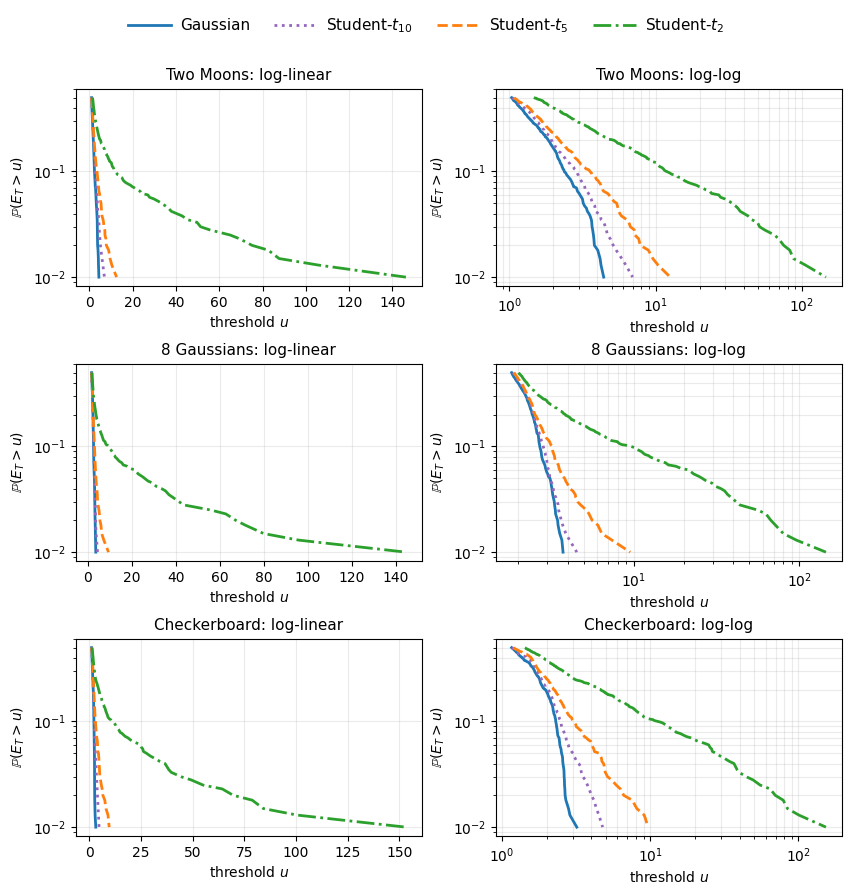

Saved: outputs_draft_energy_tail/figures/fig_empirical_E_q99.pdf
Saved: outputs_draft_energy_tail/figures/fig_empirical_E_q99.png


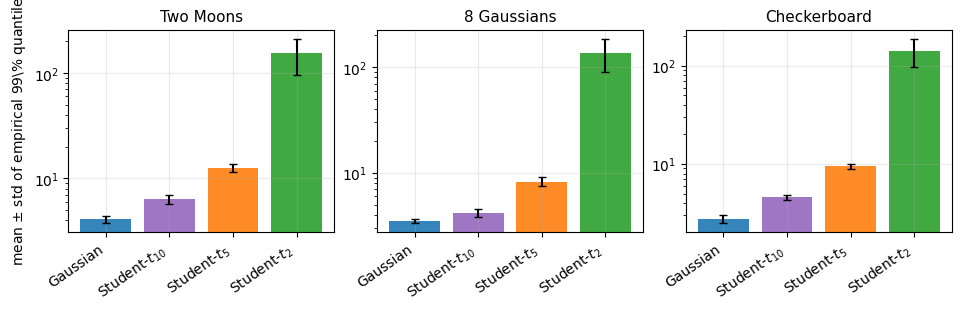

Saved: outputs_draft_energy_tail/figures/fig_sharpness_survival.pdf
Saved: outputs_draft_energy_tail/figures/fig_sharpness_survival.png


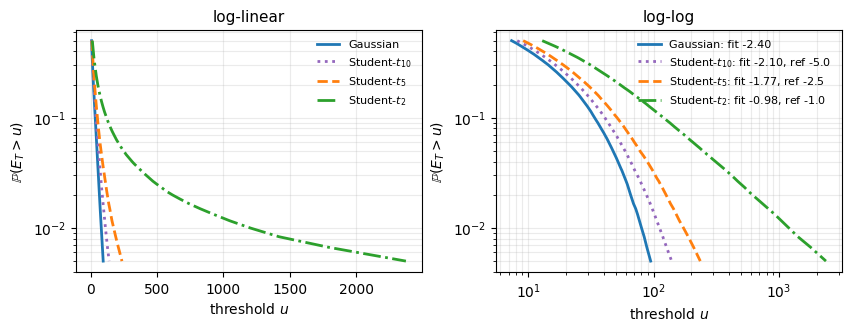

Saved: outputs_draft_energy_tail/figures/fig_empirical_Kmid_survival_appendix.pdf
Saved: outputs_draft_energy_tail/figures/fig_empirical_Kmid_survival_appendix.png


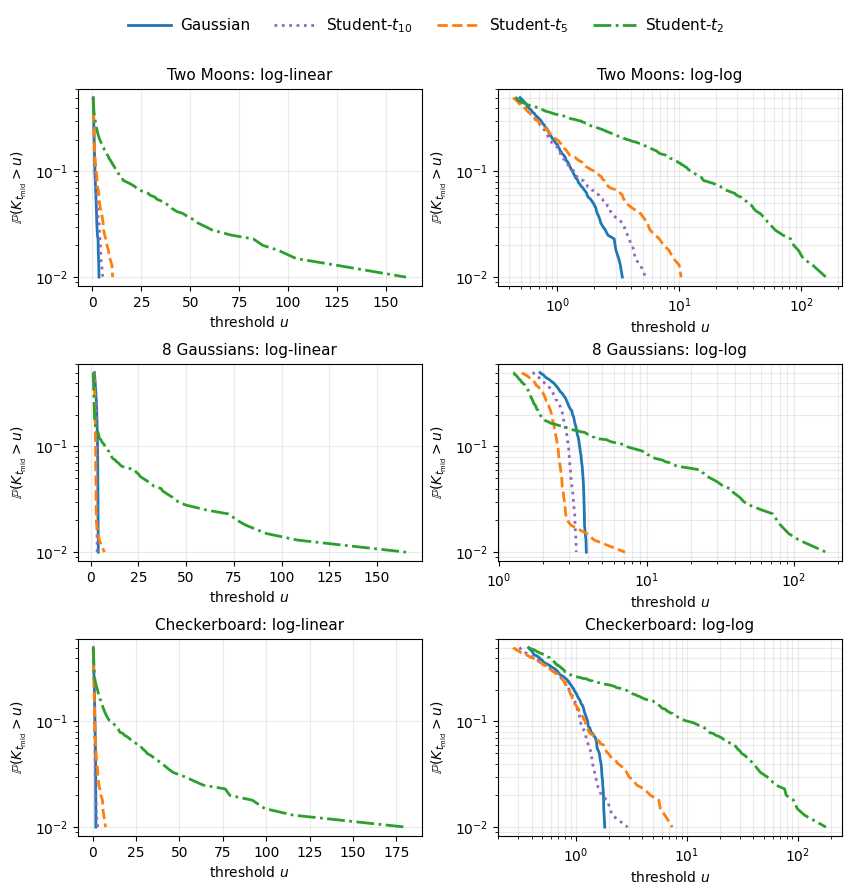

Saved: outputs_draft_energy_tail/figures/fig_empirical_endpoints_appendix.pdf
Saved: outputs_draft_energy_tail/figures/fig_empirical_endpoints_appendix.png


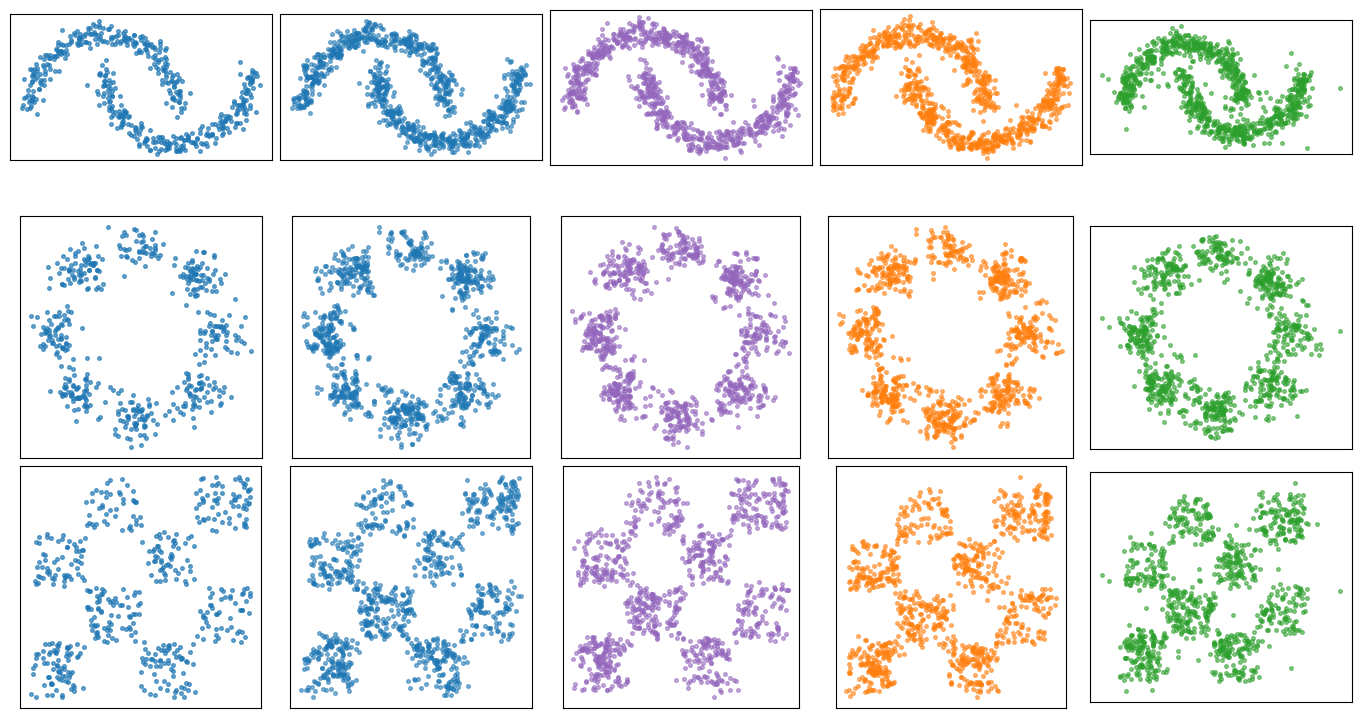

In [52]:
#@title Hidden implementation cell
# =============================================================================
# Main-text figures
# =============================================================================

if empirical_plot_payloads_first_seed:
    _ = plot_empirical_survival_grid(
        empirical_plot_payloads_first_seed,
        quantity="E_T",
        stem="fig_empirical_ET_survival",
        include_fitted_slopes=False,
    )

    _ = plot_empirical_energy_quantiles_mean_std(
        empirical_agg_df,
        metric="E_q99",
        stem="fig_empirical_E_q99",
    )
else:
    print("Empirical plot payloads unavailable. Set RUN_EMPIRICAL=True and rerun empirical experiments.")

if sharpness_plot_payloads_first_seed:
    _ = plot_sharpness_tail_results_first_seed(
        sharpness_plot_payloads_first_seed,
        stem="fig_sharpness_survival",
    )
else:
    print("Sharpness plot payloads unavailable. Set RUN_SHARPNESS=True and rerun sharpness experiments.")

# =============================================================================
# Appendix / helper figures
# =============================================================================

if empirical_plot_payloads_first_seed:
    _ = plot_empirical_survival_grid(
        empirical_plot_payloads_first_seed,
        quantity="K_mid",
        stem="fig_empirical_Kmid_survival_appendix",
        include_fitted_slopes=False,
    )

    _ = plot_empirical_generated_samples_first_seed(
        empirical_plot_payloads_first_seed,
        stem="fig_empirical_endpoints_appendix",
    )

Saved: outputs_draft_energy_tail/figures/fig_flux_null_caveat_ET.pdf
Saved: outputs_draft_energy_tail/figures/fig_flux_null_caveat_ET.png


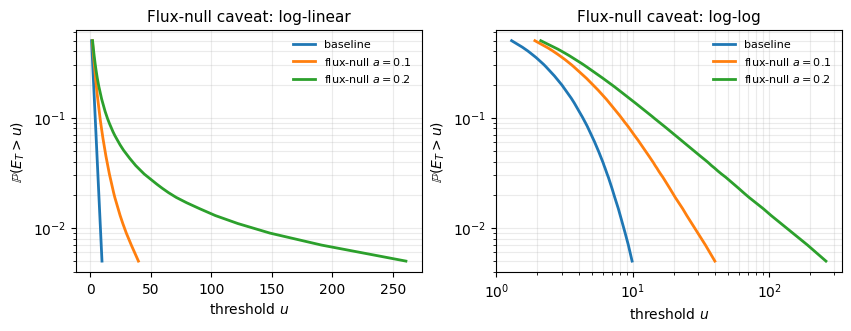

Saved: outputs_draft_energy_tail/figures/fig_flux_null_caveat_Kmid.pdf
Saved: outputs_draft_energy_tail/figures/fig_flux_null_caveat_Kmid.png


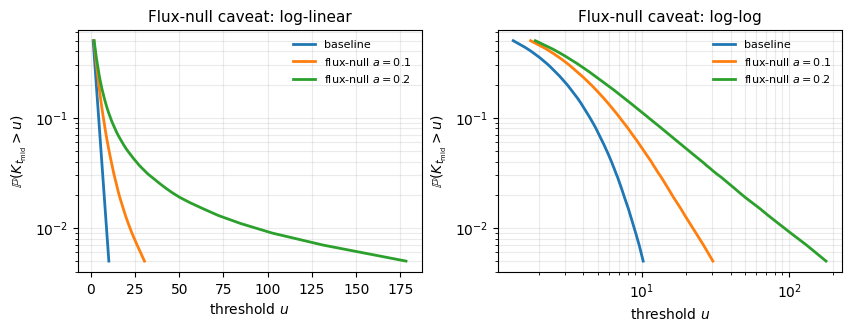

In [53]:
#@title Hidden implementation cell
# =============================================================================
# 12. Flux-null caveat experiment
# =============================================================================

def flux_null_caveat_samples(
    n: int = 200_000,
    sigma_min: float = SIGMA_MIN,
    T: float = T_END,
    t_mid_fraction: float = T_FRACTION_FOR_K,
    a_values: tuple[float, ...] = (0.10, 0.20),
    seed: int = 314159,
) -> dict:
    """
    One-point empirical variance-floored RF in d=2 with x^(1)=0.

    Baseline:
        p_hat_t = N(0, sigma_t^2 I_2)
        v_hat_t(z) = -(1-sigma_min) z / sigma_t

    Flux-null modification:
        r_t(z) = exp(a ||z||^2 / sigma_t^2) J z

    Along the flow, S = ||X0||^2 is chi-square_2 and remains the normalized radius.
    We compute exact K_mid and E_T samples without Euler integration.
    """
    rng = np.random.default_rng(seed)
    X0 = rng.standard_normal((n, 2))
    S = np.sum(X0 * X0, axis=1)  # chi-square_2

    b = 1.0 - sigma_min
    t_mid = t_mid_fraction * T
    sigma_mid = 1.0 - b * t_mid

    # Integral of sigma_t^2 from 0 to T, where sigma_t = 1 - b t.
    if abs(b) < 1e-14:
        int_sigma_sq = T
    else:
        int_sigma_sq = (1.0 - (1.0 - b * T) ** 3) / (3.0 * b)

    results = {}

    K_base = (b ** 2) * S
    E_base = (b ** 2) * T * S

    results["baseline"] = {
        "label": "baseline",
        "K_mid": K_base,
        "E_T": E_base,
    }

    for a in a_values:
        if not (0.0 < a < 0.25):
            raise ValueError("Require 0 < a < 1/4 for L2 membership.")

        K_flux = K_base + (sigma_mid ** 2) * S * np.exp(2.0 * a * S)
        E_flux = E_base + int_sigma_sq * S * np.exp(2.0 * a * S)

        results[f"flux_a={a}"] = {
            "label": rf"flux-null $a={a}$",
            "K_mid": K_flux,
            "E_T": E_flux,
        }

    return results


def plot_flux_null_caveat(
    results: dict,
    quantity: str = "E_T",
    stem: str = "fig_flux_null_caveat",
) -> plt.Figure:
    """
    Plot survival curves showing that flux-null modifications can alter energy tails.
    """
    fig, axes = plt.subplots(1, 2, figsize=(8.4, 3.2), constrained_layout=True)
    ax_lin, ax_log = axes

    for key, payload in results.items():
        values = payload[quantity]
        u, sf = empirical_survival(values, n_pts=250, q_min=0.50, q_max=0.995)
        mask = (u > 0.0) & (sf > 0.0)

        ax_lin.semilogy(u[mask], sf[mask], linewidth=2.0, label=payload["label"])
        ax_log.loglog(u[mask], sf[mask], linewidth=2.0, label=payload["label"])

    ylabel = r"$\mathbb{P}(E_T>u)$" if quantity == "E_T" else r"$\mathbb{P}(K_{t_{\rm mid}}>u)$"

    ax_lin.set_title("Flux-null caveat: log-linear")
    ax_log.set_title("Flux-null caveat: log-log")
    for ax in axes:
        ax.set_xlabel(r"threshold $u$")
        ax.set_ylabel(ylabel)
        ax.grid(True, which="both", alpha=0.25)
        ax.legend(frameon=False)

    save_figure(fig, stem)
    plt.show()
    return fig


flux_null_results = flux_null_caveat_samples(
    n=200_000,
    sigma_min=SIGMA_MIN,
    T=T_END,
    t_mid_fraction=T_FRACTION_FOR_K,
    a_values=(0.10, 0.20),
    seed=271828,
)

_ = plot_flux_null_caveat(
    flux_null_results,
    quantity="E_T",
    stem="fig_flux_null_caveat_ET",
)

_ = plot_flux_null_caveat(
    flux_null_results,
    quantity="K_mid",
    stem="fig_flux_null_caveat_Kmid",
)

# Final summary

The conceptual takeaway is:

> Empirical flow matching is not only a question of matching terminal samples.  
> The plug-in target, the selected velocity representative, the flux-null degrees of freedom, and the source distribution all shape the resulting sampler.
